### 4.2 Modeling/4.3 Feature selection

In [60]:
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, classification_report, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

def make_pipeline(classifier):
    """Creates a machine learning pipeline with a Random Forest Classifier.

    Returns:
        Pipeline: A scikit-learn pipeline with a RandomForestClassifier as the final step.
    """
    steps = [("classifier", classifier)]
    pipe = Pipeline(steps)
    return pipe

def train(df, classifier):
    """Trains a Random Forest model using the specified DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the features and target variable.

    Returns:
        Pipeline: The trained RandomForest model pipeline.
    """
    # We are predicting the protein labels
    y = df["label"]
    target = "label"
    features = list(df.columns)
    
    features.remove(target)

    # Select all columns starting with 'onehot' for features
    x = df[features]

    # Split data into train and test sets
    x_train, x_test, y_train, y_test = balanced_group_train_test_split(
        x,
        y,
        group_col='augmentated from uniprot ID',
        test_size=0.2,
        random_state=42
    )

    # Count positive and negative labels in y_train and y_test
    y_train_counts = y_train.value_counts()
    y_test_counts = y_test.value_counts()

    print("Label counts in y_train:")
    print(y_train_counts)

    print("\nLabel counts in y_test:")
    print(y_test_counts)

    trained_model = make_pipeline(classifier)
    trained_model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = trained_model.predict(x_train)
    y_test_pred = trained_model.predict(x_test)


    # Calculate model metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_mcc = matthews_corrcoef(y_train, y_train_pred)
    test_mcc = matthews_corrcoef(y_test, y_test_pred)
    
    train_report = classification_report(y_train, y_train_pred, zero_division=1)
    test_report = classification_report(y_test, y_test_pred, zero_division=1)

        # Print metrics in a readable format
    print(f"Model {classifier} Performance Metrics:\n")
    
    print("Training Data Metrics:")
    print(f"Accuracy: {train_accuracy:.2f}")
    print(f"MCC: {train_mcc:.2f}")
    print("Classification Report:")
    print(train_report)
    
    print("\nTest Data Metrics:")
    print(f"Accuracy: {test_accuracy:.2f}")
    print(f"MCC: {test_mcc:.2f}")
    print("Classification Report:")
    print(test_report)

    

    print("Successfully trained the model.")
    return trained_model

def evaluation(df, trained_model):
    """evaluation a model using the specified DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the features and target variable.

    Returns:
        None
    """
    # We are predicting the protein labels
    y = df["label"]
    target = "label"
    features = list(df.columns)
    
    features.remove(target)

    # Select all columns starting with 'onehot' for features
    x = df[features]


    # Count positive and negative labels in y_train and y_test
    y_counts = y.value_counts()

    print("Label counts in y:")
    print(y_counts)

    # Make predictions
    y_test_pred = trained_model.predict(x)


    # Calculate model metrics
    test_accuracy = accuracy_score(y, y_test_pred)
    
    test_mcc = matthews_corrcoef(y, y_test_pred)
    
    test_report = classification_report(y, y_test_pred, zero_division=1)

        # Print metrics in a readable format
    print(f"Model {trained_model} Performance Metrics:\n")
    
    
    print("\nTest Data Metrics:")
    print(f"Accuracy: {test_accuracy:.2f}")
    print(f"MCC: {test_mcc:.2f}")
    print("Classification Report:")
    print(test_report)

    print("Successfully evaluated the model.")
    return None   

In [61]:
# Customized the train_test_split for augmentated dataset
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

def balanced_group_train_test_split(X, y, group_col='augmented_from_uniprot_id', 
                                   test_size=0.2, random_state=42, drop_group_col = True):
    """
    Splits data into balanced train/test sets while keeping augmented groups together.
    
    Parameters:
    X (pd.DataFrame): Feature dataframe containing the group column
    y (pd.Series): Target labels
    group_col (str): Name of the column containing group IDs
    test_size (float): Proportion of data for testing (default 0.2)
    random_state (int): Random seed for reproducibility
    
    Returns:
    (pd.DataFrame, pd.DataFrame, pd.Series, pd.Series): X_train, X_test, y_train, y_test
    """
    # Validate inputs
    if group_col not in X.columns:
        raise ValueError(f"Group column '{group_col}' not found in feature dataframe")
        
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")

    rng = np.random.RandomState(random_state)
    combined = X.copy()
    combined['_label'] = y.values

    # Create group metadata
    group_meta = combined.groupby(group_col).agg({
        '_label': 'first',
        group_col: 'count'
    }).rename(columns={group_col: 'count'}).reset_index()

    train_groups, test_groups = [], []

    # Stratified group splitting
    for label in group_meta['_label'].unique():
        label_groups = group_meta[group_meta['_label'] == label]
        total_samples = label_groups['count'].sum()
        test_samples_target = int(total_samples * test_size)
        
        label_groups = shuffle(label_groups, random_state=rng)
        
        # Select groups for test set
        cumulative, selected = 0, []
        for _, row in label_groups.iterrows():
            if cumulative >= test_samples_target:
                break
            selected.append(row[group_col])
            cumulative += row['count']
        
        # Assign remaining groups to train
        remaining = list(set(label_groups[group_col]) - set(selected))
        test_groups.extend(selected)
        train_groups.extend(remaining)

    # Create splits
    train_mask = combined[group_col].isin(train_groups)
    test_mask = combined[group_col].isin(test_groups)

    if drop_group_col:
        return (
                X[train_mask].drop(columns=[group_col]),
                X[test_mask].drop(columns=[group_col]),
                y[train_mask],
                y[test_mask])
    else:
        return (
                X[train_mask],
                X[test_mask],
                y[train_mask],
                y[test_mask])

In [62]:
# look at the bio feature, look for the co linear feature in it 
# exclude some of those features

In [90]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]

In [91]:
excluded_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_',
    'onehot_'
)

exclude_columns = ['Unnamed: 0', 'uniprot_id', 'sequence', 'site',  'human Site and Mutation', 'usage',
       'unique_id', "anchor_score", "augmentated from uniprot ID"]

# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
bio_columns_to_keep = [col for col in columns_to_keep if col not in exclude_columns]
# Now select those columns from your DataFrame
biology_training_dataset_df = training_dataset_df[bio_columns_to_keep]

In [92]:
biology_training_dataset_df.head(2)

,label,deephase_phys_multi,deephase_w2v_multi,deephase_score,iupred_score,nuSVR,SconfSVR/N (kB),mean_lambda,SHD,SCD,kappa,FCR,NCPR,fK,fR,fE,fD,faro,phospho_score
0,1,0.203,0.160,0.182,0.541878,0.556,10.595,0.324,1.403,-0.950,0.363,0.385,-0.077,0.077,0.077,0.0,0.154,0.0,0.526
1,1,0.185,0.173,0.179,0.509769,0.732,10.867,0.388,0.970,-0.546,-1.000,0.600,0.200,0.200,0.200,0.0,0.000,0.0,0.579


In [93]:
biology_training_dataset_df.columns

Index(['label', 'deephase_phys_multi', 'deephase_w2v_multi', 'deephase_score',
       'iupred_score', 'nuSVR', 'SconfSVR/N (kB)', 'mean_lambda', 'SHD', 'SCD',
       'kappa', 'FCR', 'NCPR', 'fK', 'fR', 'fE', 'fD', 'faro',
       'phospho_score'],
      dtype='object')

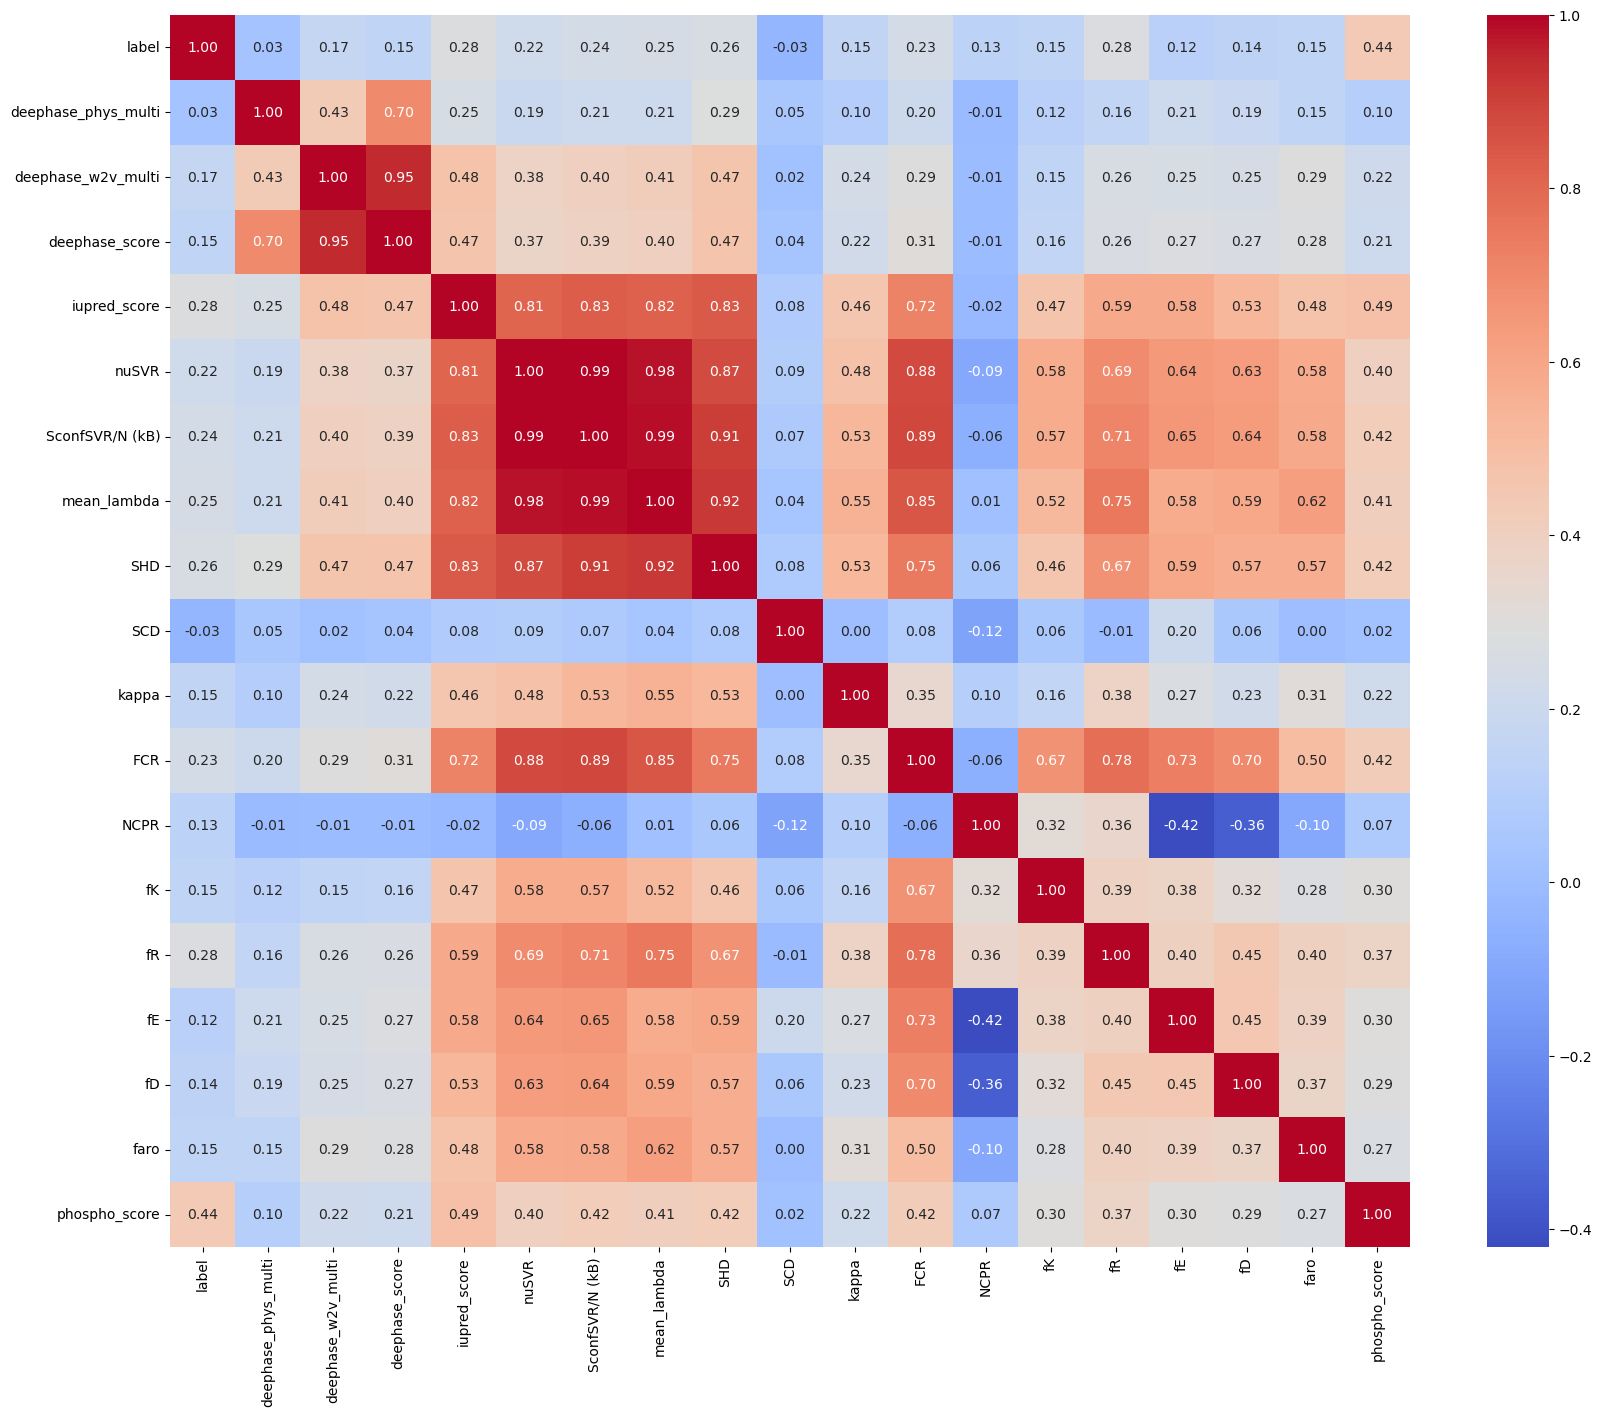

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set the figure size
plt.figure(figsize=(20, 16))  # Adjust the size as needed

# Create the heatmap
sns.heatmap(biology_training_dataset_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

# Show the plot
plt.show()

In [95]:
always_exclude_columns = ['Unnamed: 0', 'uniprot_id', 'sequence', 'site',  'human Site and Mutation', 'usage','unique_id', 
                          "anchor_score", 'onehot_0_s', 'onehot_0_t', 'deephase_w2v_multi', 'deephase_phys_multi', 
                          'SconfSVR/N (kB)', 'mean_lambda', 'SHD', 'fE', 'fD']

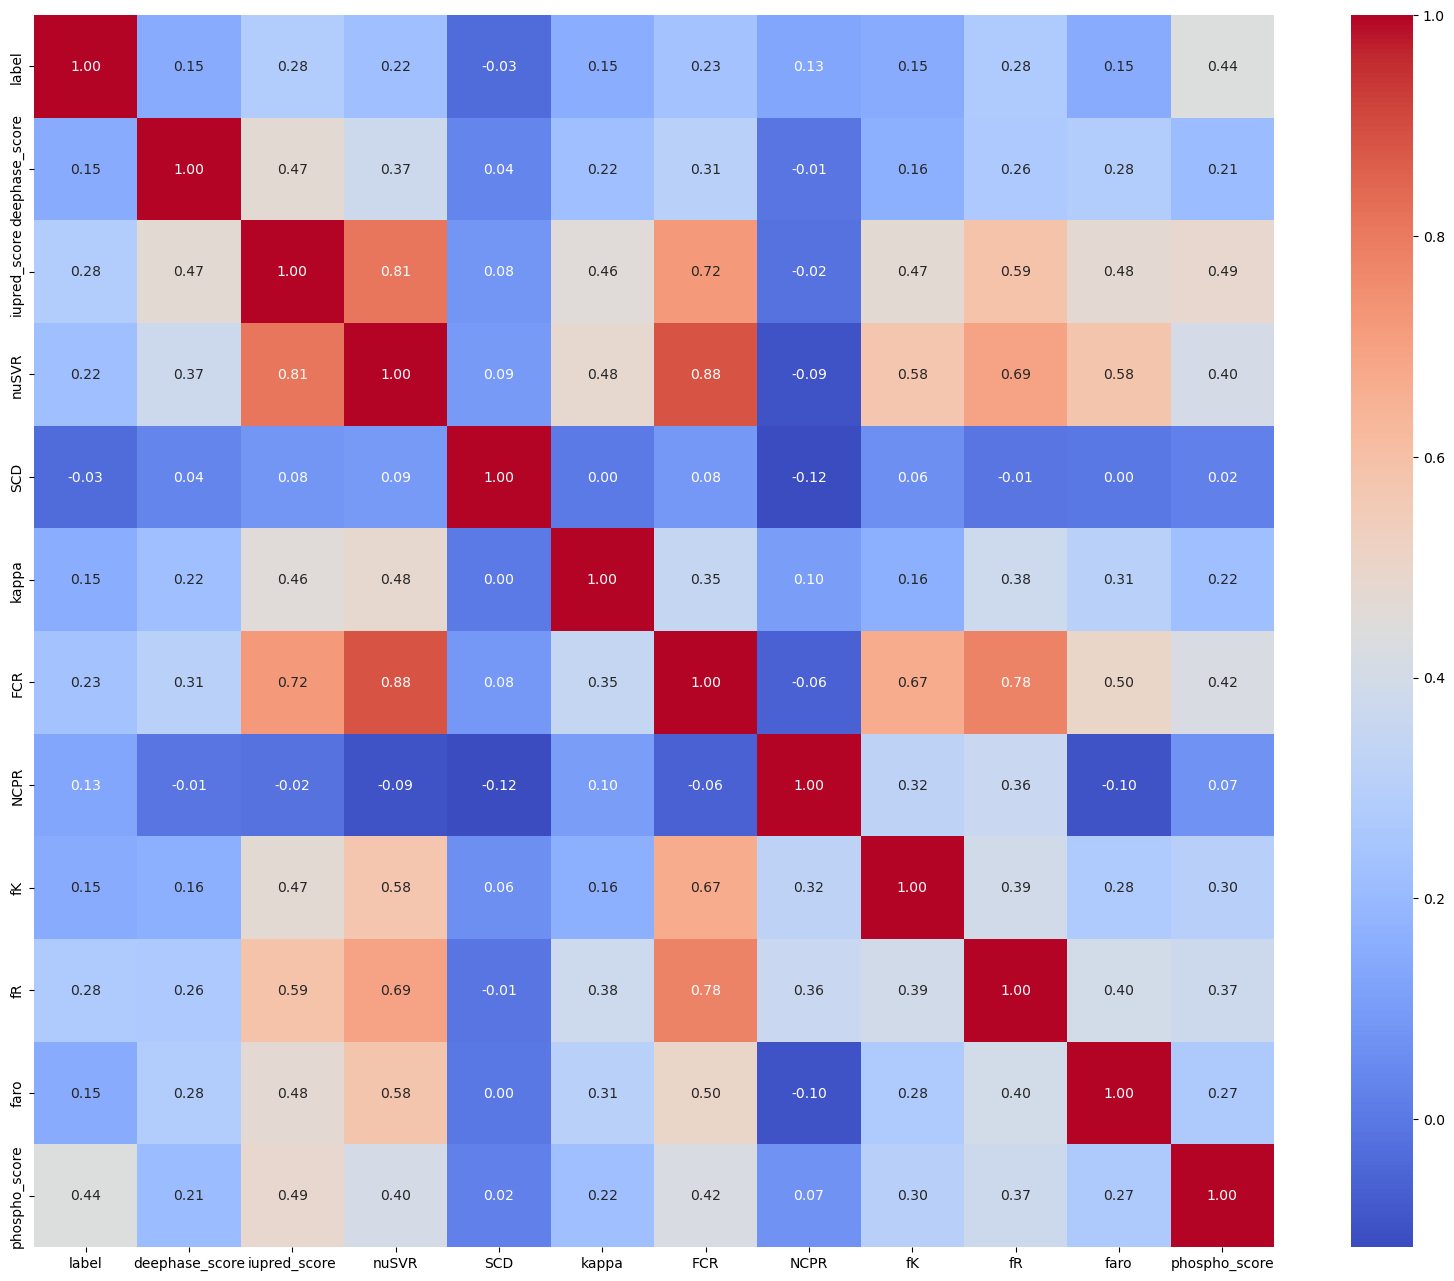

In [96]:
# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
bio_columns_to_keep = [col for col in columns_to_keep if col not in always_exclude_columns]
# Now select those columns from your DataFrame
bio_columns_to_keep.remove("augmentated from uniprot ID")

biology_training_dataset_df = training_dataset_df[bio_columns_to_keep]

# Set the figure size
plt.figure(figsize=(20, 16))  # Adjust the size as needed

# Create the heatmap
sns.heatmap(biology_training_dataset_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

# Show the plot
plt.show()

# task 35: # 1. prove data augmentation is helpful for modeling
# model from no_augmentated model compare with augmentated model using only onehot encode

In [110]:
# get augmentated and no_augmentated training dataset, only include onehot encode feature
dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")

# get independent test dataset, only include onehot encode feature
training_dataset_df = dataset_df[dataset_df["usage"] == "training"]
no_postive_augmentated_training_dataset_df = training_dataset_df[training_dataset_df["uniprot_id"]==training_dataset_df["augmentated from uniprot ID"]]

In [111]:
negative_dataset = pd.read_csv("labeled_and_augmented_negative_data.csv")
negative_dataset.head(2)

,Unnamed: 0,index,uniqueid,uniprot_id,position,prot_id_position,protein_length,iupred_score,anchor_score,phospho_score,binned_protein_length,binned_iupred_score,binned_anchor_score,binned_phospho_score,stratification_label,label,augmentated data?,homology data?
0,0,309110,P51843_S_457,P51843,457,P51843_457,470,0.013821,0.424671,0.044,0,0,1,0,0_0_1_0,0,1,0
1,1,270130,P62324_S_90,P62324,90,P62324_90,171,0.185198,0.427061,0.105,0,0,1,0,0_0_1_0,0,1,0


In [112]:
def filter_out_augmented_entries(main_df, negative_df):
    """
    Filter out rows from main_df where the same uniprot_id and position 
    are labeled as augmented in negative_df.
    
    Args:
        main_df (pd.DataFrame): The main dataframe to filter
        negative_df (pd.DataFrame): The negative dataset with augmented labels
        
    Returns:
        pd.DataFrame: Filtered dataframe
    """
    # Find augmented entries in the negative dataset
    augmented_negative = negative_df[negative_df['augmentated data?'] == 1]
    
    # Create a set of (uniprot_id, position) pairs that are augmented in negative dataset
    augmented_pairs = set(zip(augmented_negative['uniprot_id'], augmented_negative['position']))
    
    # Filter the main dataframe to exclude rows with matching (uniprot_id, position) pairs
    filtered_df = main_df[~main_df.apply(
        lambda row: (row['uniprot_id'], row['site']) in augmented_pairs, 
        axis=1
    )]
    
    return filtered_df

In [113]:
# exclude the negative augmentated dataset
no_augmentated_training_dataset_df = filter_out_augmented_entries(no_postive_augmentated_training_dataset_df, negative_dataset)

In [114]:
no_augmentated_training_dataset_df

,Unnamed: 0,uniprot_id,sequence,site,label,augmentated from uniprot ID,human Site and Mutation,usage,unique_id,deephase_phys_multi,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
656,656,Q12809,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1137,1,Q12809,S1137s,training,Q12809_1137_MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANA...,0.251,...,-1.783180,-0.304031,-0.288107,0.164548,-0.551381,-0.128719,-1.041860,0.181813,-0.047576,0.536
657,657,Q12809,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,283,1,Q12809,S283s,training,Q12809_283_MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANAR...,0.251,...,-1.806326,-0.828657,0.649456,1.450973,0.653022,-0.550002,-1.043735,0.340695,-0.834819,0.559
661,661,Q53EL6,MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEEIKNEINGNWIS...,457,1,Q53EL6,S457s,training,Q53EL6_457_MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEE...,0.253,...,-1.038290,-1.411181,-0.506342,-1.455358,1.592491,1.660902,0.631469,-0.082601,-0.395762,0.574
662,662,Q53EL6,MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEEIKNEINGNWIS...,76,1,Q53EL6,S76s,training,Q53EL6_76_MDVENEQILNVNPADPDNLSDSLFSGDEENAGTEEI...,0.253,...,-2.255229,-0.687755,-0.409781,-0.000571,-0.095428,1.090727,-0.278532,-0.292084,-0.407974,0.792
667,667,Q16584,MEPLKSLFLKSPLGSWNGSGSGGGGGGGGGRPEGSPKAAGYANPVW...,477,1,Q16584,T477t,training,Q16584_477_MEPLKSLFLKSPLGSWNGSGSGGGGGGGGGRPEGS...,0.279,...,-1.110806,0.015970,0.010673,0.165749,-0.105785,-0.907999,-0.538865,0.178536,-0.496697,0.540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512,1512,P07359,MPLLLLLLLLPSPLHPHPICEVSKVASHLEVNCDKRNLTALPPDLP...,163,0,P07359,T163t,training,P07359_163_MPLLLLLLLLPSPLHPHPICEVSKVASHLEVNCDK...,0.184,...,-2.151117,-0.365751,0.100583,0.527544,0.326141,-0.702853,0.042790,2.066671,0.122529,0.036
2188,2188,Q8WV28,MDKLNKITVPASQKLRQLQKMVHDIKNNEGGIMNKIKKLKVKAPPS...,144,0,Q8WV28,S144s,training,Q8WV28_144_MDKLNKITVPASQKLRQLQKMVHDIKNNEGGIMNK...,0.268,...,-2.612988,0.002217,1.884787,0.551916,0.957121,0.635466,-1.360663,1.111972,1.553928,0.041
2213,2213,Q5D1E8,MSGPCGEKPVLEASPTMSLWEFEDSHSRQGTPRPGQELAAEEASAL...,362,0,Q5D1E8,S362s,training,Q5D1E8_362_MSGPCGEKPVLEASPTMSLWEFEDSHSRQGTPRPG...,0.278,...,-2.303561,0.059922,0.788983,-0.363295,0.234735,0.931589,-0.319640,1.455369,-0.062593,0.269
2225,2225,Q96E09,MAQEKMELDLELPPGTGGSPAEGGGSGGGGGLRRSNSAPLIHGLSD...,122,0,Q96E09,S122s,training,Q96E09_122_MAQEKMELDLELPPGTGGSPAEGGGSGGGGGLRRS...,0.191,...,-1.569469,-0.652345,0.701813,0.122008,0.720703,1.335228,0.233918,-0.800321,0.051862,0.054


In [116]:
onehot_augmentated_dataset_df = training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_no_augmentated_dataset_df = no_augmentated_training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_test_dataset_df = dataset_df[dataset_df["usage"] == "independent test"].filter(regex=r'^(onehot_|label)')

In [117]:
# training two model
augmentated_model = train(onehot_augmentated_dataset_df, RandomForestClassifier(max_depth=7))
no_augmentated_model = train(onehot_no_augmentated_dataset_df, RandomForestClassifier(max_depth=7))

Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7) Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       966
           1       0.89      0.89      0.89       841

    accuracy                           0.90      1807
   macro avg       0.90      0.90      0.90      1807
weighted avg       0.90      0.90      0.90      1807


Test Data Metrics:
Accuracy: 0.82
MCC: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       233
           1       0.85      0.76      0.80       226

    accuracy                           0.82       459
   macro avg       0.82      0.82      0.82       459
weighted avg       0.82      0.82      0.82     

In [118]:
# evaluate both model in independent test dataset

In [119]:
print("evaluate model trained with augmentated data")
evaluation(onehot_test_dataset_df, augmentated_model)

evaluate model trained with augmentated data
Label counts in y:
label
0    264
1    263
Name: count, dtype: int64
Model Pipeline(steps=[('classifier', RandomForestClassifier(max_depth=7))]) Performance Metrics:


Test Data Metrics:
Accuracy: 0.80
MCC: 0.63
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.95      0.83       264
           1       0.92      0.65      0.77       263

    accuracy                           0.80       527
   macro avg       0.83      0.80      0.80       527
weighted avg       0.83      0.80      0.80       527

Successfully evaluated the model.


In [120]:
print("evaluate model trained with no augmentated data")
evaluation(onehot_test_dataset_df, no_augmentated_model)

evaluate model trained with no augmentated data
Label counts in y:
label
0    264
1    263
Name: count, dtype: int64
Model Pipeline(steps=[('classifier', RandomForestClassifier(max_depth=7))]) Performance Metrics:


Test Data Metrics:
Accuracy: 0.77
MCC: 0.57
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.95      0.80       264
           1       0.92      0.58      0.71       263

    accuracy                           0.77       527
   macro avg       0.81      0.77      0.76       527
weighted avg       0.81      0.77      0.76       527

Successfully evaluated the model.


task 37: Then we tested modeling from multi-scale biology features plus onehot encoding for the -7 to +7 motif, the result show that multi-scale biology features also can be used to predict the 14-3-3 binding when compare with only use onehot encoded motif feature. 

In [74]:
# we first test to only use onehot encoding for the prediction

In [75]:
onehot_training_dataset_df = training_dataset_df.filter(regex=r'^(onehot_|label|augmentated from uniprot ID)')
onehot_training_dataset_df

,label,augmentated from uniprot ID,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,onehot_-7_H,onehot_-7_I,...,onehot_7_P,onehot_7_Q,onehot_7_R,onehot_7_S,onehot_7_T,onehot_7_V,onehot_7_W,onehot_7_Y,onehot_7_s,onehot_7_t
0,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,P16333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Q5VWQ8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,0,O15417,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2262,0,Q9BYW2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2263,0,Q8N3K9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2264,0,Q6ZRS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
print(f"Modeling only use onehot encoding features")
model = train(onehot_training_dataset_df, RandomForestClassifier(max_depth=7))

Modeling only use onehot encoding features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7) Performance Metrics:

Training Data Metrics:
Accuracy: 0.91
MCC: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       966
           1       0.90      0.90      0.90       841

    accuracy                           0.91      1807
   macro avg       0.91      0.91      0.91      1807
weighted avg       0.91      0.91      0.91      1807


Test Data Metrics:
Accuracy: 0.84
MCC: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       233
           1       0.85      0.81      0.83       226

    accuracy                           0.84       459
   macro avg       0.84      0.84      0.84       459
weigh

In [77]:
# then we test use both onehot encode and biological features

In [78]:
excluded_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_'
)

# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
bio_columns_to_keep = [col for col in columns_to_keep if col not in always_exclude_columns]
# Now select those columns from your DataFrame
biology_training_dataset_df = training_dataset_df[bio_columns_to_keep]

In [79]:
biology_training_dataset_df.head(2)

,label,augmentated from uniprot ID,deephase_score,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,onehot_-7_F,onehot_-7_G,...,onehot_7_Y,onehot_7_s,onehot_7_t,nuSVR,SCD,kappa,NCPR,fK,fR,phospho_score
0,1,P16333,0.182,0.541878,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.556,-0.950,0.363,-0.077,0.077,0.077,0.526
1,1,P16333,0.179,0.509769,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.732,-0.546,-1.000,0.200,0.200,0.200,0.579


In [80]:
print(f"Modeling using multi-scale biology features")
model = train(biology_training_dataset_df, RandomForestClassifier(max_depth=7))

Modeling using multi-scale biology features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7) Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       966
           1       0.89      0.90      0.90       841

    accuracy                           0.90      1807
   macro avg       0.90      0.90      0.90      1807
weighted avg       0.90      0.90      0.90      1807


Test Data Metrics:
Accuracy: 0.85
MCC: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       233
           1       0.87      0.81      0.84       226

    accuracy                           0.85       459
   macro avg       0.85      0.85      0.85       459
weig

In [53]:
import gc
gc.collect()

6001106

task 36: modeling direct from only PLM embedding, we first compare using embeddings from either ESM2 or PTM-mamba to represent the whole protein or the residue embeddings, 

In [6]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]

In [7]:
training_dataset_df.head(2)

,Unnamed: 0,uniprot_id,sequence,site,label,augmentated from uniprot ID,human Site and Mutation,usage,unique_id,deephase_phys_multi,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,0,H7C5C7,XVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMNKTGFVPSNYVER...,73,1,P16333,S73s,training,H7C5C7_73_XVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMNKT...,0.203,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,A0A5F9CW23,MAEEVVVVAKFDYVAQQEQELDIKKNERLWLLDDSKSWWRVRNSMN...,85,1,P16333,S85s,training,A0A5F9CW23_85_MAEEVVVVAKFDYVAQQEQELDIKKNERLWLL...,0.185,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579
2,2,Q5RF68,MDWLNVFKDFFSIGKVKRKPsVPDSASPADDSFVDPGERLYDLNMP...,21,1,P16333,S21s,training,Q5RF68_21_MDWLNVFKDFFSIGKVKRKPsVPDSASPADDSFVDP...,0.096,...,-1.474621,-0.104392,1.062815,0.442375,-0.308503,-0.050680,-1.171706,1.861005,0.189925,0.571
3,3,H3A391,MTEEVTVIAKFDYVAQQEQELDIKKNEKLLLLDDSKSWWRVRNSMN...,85,1,P16333,S85s,training,H3A391_85_MTEEVTVIAKFDYVAQQEQELDIKKNEKLLLLDDSK...,0.108,...,-0.708835,-0.368524,0.630111,0.287115,0.439652,0.259266,-1.870489,2.179887,0.830376,0.379
4,4,A0A8J1IQP6,MSLNGRRGSGRPGYYYRLIGRSQLQRQRSRSRSRNRPARRESPPER...,725,1,Q5VWQ8,S725s,training,A0A8J1IQP6_725_MSLNGRRGSGRPGYYYRLIGRSQLQRQRSRS...,0.282,...,-0.940106,-0.094523,0.474609,-0.267281,-0.266375,0.243640,-0.773728,1.224039,-0.136662,0.374


In [8]:
columns = training_dataset_df.columns
columns

Index(['Unnamed: 0', 'uniprot_id', 'sequence', 'site', 'label',
       'augmentated from uniprot ID', 'human Site and Mutation', 'usage',
       'unique_id', 'deephase_phys_multi',
       ...
       'ptmmamba_residue_embedding_759', 'ptmmamba_residue_embedding_760',
       'ptmmamba_residue_embedding_761', 'ptmmamba_residue_embedding_762',
       'ptmmamba_residue_embedding_763', 'ptmmamba_residue_embedding_764',
       'ptmmamba_residue_embedding_765', 'ptmmamba_residue_embedding_766',
       'ptmmamba_residue_embedding_767', 'phospho_score'],
      dtype='object', length=4454)

In [10]:
esm_training_dataset_df = training_dataset_df.filter(regex=r'^(esm_protein_embedding_|esm_residue_embedding_|label|augmentated from uniprot ID)')
ptmmamba_training_dataset_df = training_dataset_df.filter(regex=r'^(ptmmamba_residue_embedding|ptmmamba_protein_embedding_position|label|augmentated from uniprot ID)')

In [11]:
esm_training_dataset_df.head(2)

,label,augmentated from uniprot ID,esm_protein_embedding_0,esm_protein_embedding_1,esm_protein_embedding_2,esm_protein_embedding_3,esm_protein_embedding_4,esm_protein_embedding_5,esm_protein_embedding_6,esm_protein_embedding_7,...,esm_residue_embedding_1270,esm_residue_embedding_1271,esm_residue_embedding_1272,esm_residue_embedding_1273,esm_residue_embedding_1274,esm_residue_embedding_1275,esm_residue_embedding_1276,esm_residue_embedding_1277,esm_residue_embedding_1278,esm_residue_embedding_1279
0,1,P16333,0.021365,-0.020171,0.021621,0.095043,-0.057202,-0.050794,0.071949,0.006663,...,0.156998,-0.048794,-0.288164,-0.169802,-0.087454,-0.099428,-0.027398,-0.170118,-0.108479,-0.087466
1,1,P16333,0.024337,-0.044602,0.026486,0.129851,-0.089049,-0.042135,0.083374,0.002857,...,0.155553,-0.035488,-0.296511,-0.183268,-0.062212,-0.104337,-0.041655,-0.249533,-0.119220,-0.131040
2,1,P16333,0.019708,-0.037163,0.012426,0.091465,-0.085954,-0.071278,0.061197,0.026536,...,0.057347,-0.025978,-0.107604,-0.075288,-0.089051,-0.013340,0.077709,-0.006540,-0.176868,-0.109933
3,1,P16333,0.016691,-0.067765,-0.026445,0.096103,-0.135539,-0.088490,0.060594,-0.063513,...,0.172102,-0.006700,-0.067678,-0.127333,-0.010801,-0.093588,-0.160996,-0.111260,-0.075962,-0.120771
4,1,Q5VWQ8,0.028754,-0.000879,0.022422,0.037734,-0.101758,-0.097661,0.048510,0.022037,...,0.104533,0.161240,-0.105866,-0.053904,-0.058608,-0.270229,-0.001867,0.031717,-0.097747,-0.078485


In [12]:
ptmmamba_training_dataset_df.head(2)

,label,augmentated from uniprot ID,ptmmamba_protein_embedding_position_0,ptmmamba_protein_embedding_position_1,ptmmamba_protein_embedding_position_2,ptmmamba_protein_embedding_position_3,ptmmamba_protein_embedding_position_4,ptmmamba_protein_embedding_position_5,ptmmamba_protein_embedding_position_6,ptmmamba_protein_embedding_position_7,...,ptmmamba_residue_embedding_758,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767
0,1,P16333,0.306219,0.075793,0.279163,0.129615,-0.124552,0.055463,-0.138853,-0.701024,...,0.905219,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624
1,1,P16333,0.164579,-0.161845,0.364336,0.196843,-0.142813,-0.032246,-0.274839,-0.841149,...,1.007017,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350
2,1,P16333,0.119370,-0.170645,0.069318,0.130563,0.066603,-0.061079,0.007130,-0.659120,...,0.972614,-1.474621,-0.104392,1.062815,0.442375,-0.308503,-0.050680,-1.171706,1.861005,0.189925
3,1,P16333,0.252884,-0.104365,0.170443,0.096454,0.100202,-0.116983,-0.210762,-0.806122,...,0.809762,-0.708835,-0.368524,0.630111,0.287115,0.439652,0.259266,-1.870489,2.179887,0.830376
4,1,Q5VWQ8,0.218763,0.069228,0.227428,0.684456,0.372327,-0.193287,-0.635183,-0.696890,...,0.046559,-0.940106,-0.094523,0.474609,-0.267281,-0.266375,0.243640,-0.773728,1.224039,-0.136662


In [13]:
plm_feature_df_lst = [esm_training_dataset_df, ptmmamba_training_dataset_df]
plm_name_lst = ["esm", "ptmmamba"]

In [14]:
for name, loaded_df in zip(plm_name_lst, plm_feature_df_lst):
    print(f"Modeling using {name}")
    model = train(loaded_df, RandomForestClassifier(max_depth=7))

Modeling using esm
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7) Performance Metrics:

Training Data Metrics:
Accuracy: 0.97
MCC: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       966
           1       0.96      0.96      0.96       841

    accuracy                           0.97      1807
   macro avg       0.97      0.97      0.97      1807
weighted avg       0.97      0.97      0.97      1807


Test Data Metrics:
Accuracy: 0.80
MCC: 0.61
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.94      0.82       233
           1       0.91      0.65      0.76       226

    accuracy                           0.80       459
   macro avg       0.82      0.79      0.79       459
weighted avg       0.82      

In [15]:
import gc
gc.collect()

75

task 38: We then test using both PLM and biology features, the results show that using both PLM and biology features shows improved results compared with using only PLM or multi-scale biology features. 

In [24]:
columns_to_keep = [col for col in training_dataset_df.columns if col not in always_exclude_columns]
plm_bio_features_training_dataset_df = training_dataset_df[columns_to_keep]

,label,augmentated from uniprot ID,deephase_phys_multi,deephase_w2v_multi,deephase_score,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,1,P16333,0.203,0.160,0.182,0.541878,0.0,0.0,0.0,0.0,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,P16333,0.185,0.173,0.179,0.509769,0.0,0.0,0.0,0.0,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579
2,1,P16333,0.096,0.129,0.113,0.465241,0.0,0.0,0.0,0.0,...,-1.474621,-0.104392,1.062815,0.442375,-0.308503,-0.050680,-1.171706,1.861005,0.189925,0.571
3,1,P16333,0.108,0.352,0.230,0.566480,0.0,0.0,0.0,0.0,...,-0.708835,-0.368524,0.630111,0.287115,0.439652,0.259266,-1.870489,2.179887,0.830376,0.379
4,1,Q5VWQ8,0.282,0.742,0.512,0.837511,0.0,0.0,0.0,0.0,...,-0.940106,-0.094523,0.474609,-0.267281,-0.266375,0.243640,-0.773728,1.224039,-0.136662,0.374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,0,O15417,0.329,0.774,0.552,0.798249,0.0,0.0,0.0,0.0,...,-1.177676,-0.877304,0.674698,-0.195342,0.283925,0.078973,0.930381,0.637896,-0.366109,0.080
2262,0,Q9BYW2,0.283,0.776,0.530,0.831250,0.0,0.0,0.0,0.0,...,-1.549038,-0.295345,-0.262526,-0.634858,-0.357382,0.593850,-0.580129,0.019379,-0.784574,0.274
2263,0,Q8N3K9,0.203,0.726,0.464,0.566480,0.0,0.0,0.0,0.0,...,-0.909634,-0.845351,-0.325931,-0.011938,-0.855250,-0.535025,0.514734,0.020328,-0.189157,0.063
2264,0,Q6ZRS2,0.411,0.762,0.587,0.930790,0.0,0.0,0.0,0.0,...,-1.190711,0.183619,1.008728,-0.325716,-1.453191,-0.757268,-0.204297,0.862000,-1.027532,0.155


In [25]:
import gc

# Do some memory-intensive work here

# Force garbage collection
gc.collect()

print(f"Modeling using both PLM and biology features")
model = train(plm_bio_features_training_dataset_df, RandomForestClassifier(max_depth=7))

Modeling using both PLM and biology features
Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7) Performance Metrics:

Training Data Metrics:
Accuracy: 0.98
MCC: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       966
           1       0.97      0.99      0.98       841

    accuracy                           0.98      1807
   macro avg       0.98      0.98      0.98      1807
weighted avg       0.98      0.98      0.98      1807


Test Data Metrics:
Accuracy: 0.80
MCC: 0.63
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83       233
           1       0.90      0.67      0.77       226

    accuracy                           0.80       459
   macro avg       0.83      0.80      0.80       459
wei

In [26]:
import gc
gc.collect()

50

task 39: feature selection using mRMR. We mainly test how many features are optimized for our model by using different number of features to fit the model and compare the model performance.

In [86]:
# !pip install mrmr_selection

In [87]:
from mrmr import mrmr_classif
from sklearn.metrics import accuracy_score, classification_report, matthews_corrcoef
def mrmr_search_feature_number(df, classifier):
    y = df["label"]
    target = "label"
    features = list(df.columns)
    features.remove(target)
    x = df[features]

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = balanced_group_train_test_split(
        x,
        y,
        group_col='augmentated from uniprot ID',
        test_size=0.2,
        random_state=42
    )

    feature_number_lst = [5,10,20,25,30,40,50,100,200]
    for feature_number in feature_number_lst:
        # using mrmr to get the selected features order
        selected_features = mrmr_classif(X=X_train, y=y_train, K=feature_number)
        print(f"selected feature number is {len(selected_features)}")
        print(selected_features)

        X_train_temp = (X_train).copy()[selected_features]
        X_test_temp = X_test.copy()[selected_features]

        trained_model = make_pipeline(classifier)
        trained_model.fit(X_train_temp, y_train)

        # Make predictions
        y_train_pred = trained_model.predict(X_train_temp)
        y_test_pred = trained_model.predict(X_test_temp)

        # Calculate model metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        train_mcc = matthews_corrcoef(y_train, y_train_pred)
        test_mcc = matthews_corrcoef(y_test, y_test_pred)
        
        train_report = classification_report(y_train, y_train_pred, zero_division=1)
        test_report = classification_report(y_test, y_test_pred, zero_division=1)
        
        # Print metrics in a readable format
        print("Model Performance Metrics:\n")
        
        print("Training Data Metrics:")
        print(f"Accuracy: {train_accuracy:.2f}")
        print(f"MCC: {train_mcc:.2f}")
        print("Classification Report:")
        print(train_report)
        
        print("\nTest Data Metrics:")
        print(f"Accuracy: {test_accuracy:.2f}")
        print(f"MCC: {test_mcc:.2f}")
        print("Classification Report:")
        print(test_report)
        
        print(f"\nSuccessfully trained the model with {len(selected_features)} feature{'s' if len(selected_features) > 1 else ''}.")

In [88]:
# first mrmr selection on the biological features

In [89]:
print("biological features mrmr selection")
mrmr_search_feature_number(biology_training_dataset_df, RandomForestClassifier(max_depth=7))

biological features mrmr selection


100%|██████████| 5/5 [00:00<00:00,  8.55it/s]


selected feature number is 5
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.88
MCC: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       966
           1       0.85      0.90      0.87       841

    accuracy                           0.88      1807
   macro avg       0.88      0.88      0.88      1807
weighted avg       0.88      0.88      0.88      1807


Test Data Metrics:
Accuracy: 0.82
MCC: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       233
           1       0.83      0.79      0.81       226

    accuracy                           0.82       459
   macro avg       0.82      0.82      0.82       459
weighted avg       0.82      0.82      0.82       459


Successfully trained the model with 5 features.


100%|██████████| 10/10 [00:00<00:00, 35.11it/s]


selected feature number is 10
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'fR', 'onehot_1_P', 'onehot_4_L']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.89
MCC: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       966
           1       0.86      0.90      0.88       841

    accuracy                           0.89      1807
   macro avg       0.89      0.89      0.89      1807
weighted avg       0.89      0.89      0.89      1807


Test Data Metrics:
Accuracy: 0.84
MCC: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       233
           1       0.85      0.83      0.84       226

    accuracy                           0.84       459
   macro avg       0.84      0.84      0.84       459
weighted avg       0.84      0.84      0.84       459


Successf

...

selected feature number is 50
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'fR', 'onehot_1_P', 'onehot_4_L', 'onehot_-4_R', 'onehot_-3_V', 'onehot_-3_S', 'iupred_score', 'onehot_-2_G', 'onehot_2_K', 'onehot_-3_D', 'onehot_-2_R', 'onehot_1_R', 'onehot_-1_H', 'onehot_-3_G', 'onehot_-3_A', 'onehot_-3_N', 'onehot_-5_R', 'onehot_-3_L', 'onehot_3_D', 'onehot_-3_P', 'nuSVR', 'onehot_2_I', 'onehot_4_Q', 'onehot_-1_D', 'onehot_-3_Q', 'onehot_2_A', 'onehot_-5_N', 'NCPR', 'onehot_-2_N', 'onehot_2_F', 'deephase_score', 'onehot_1_E', 'onehot_-1_G', 'onehot_-2_D', 'onehot_-2_L', 'onehot_5_H', 'onehot_1_G', 'onehot_7_G', 'fK', 'onehot_1_A', 'onehot_-6_G', 'onehot_-2_F', 'onehot_-1_N']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.90
MCC: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       966
           1       0.88      0.90      0.89       84

100%|██████████| 100/100 [00:03<00:00, 33.23it/s]


selected feature number is 100
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'fR', 'onehot_1_P', 'onehot_4_L', 'onehot_-4_R', 'onehot_-3_V', 'onehot_-3_S', 'iupred_score', 'onehot_-2_G', 'onehot_2_K', 'onehot_-3_D', 'onehot_-2_R', 'onehot_1_R', 'onehot_-1_H', 'onehot_-3_G', 'onehot_-3_A', 'onehot_-3_N', 'onehot_-5_R', 'onehot_-3_L', 'onehot_3_D', 'onehot_-3_P', 'nuSVR', 'onehot_2_I', 'onehot_4_Q', 'onehot_-1_D', 'onehot_-3_Q', 'onehot_2_A', 'onehot_-5_N', 'NCPR', 'onehot_-2_N', 'onehot_2_F', 'deephase_score', 'onehot_1_E', 'onehot_-1_G', 'onehot_-2_D', 'onehot_-2_L', 'onehot_5_H', 'onehot_1_G', 'onehot_7_G', 'fK', 'onehot_1_A', 'onehot_-6_G', 'onehot_-2_F', 'onehot_-1_N', 'onehot_2_L', 'onehot_-2_V', 'onehot_-3_W', 'onehot_-2_E', 'kappa', 'onehot_-4_K', 'onehot_-5_T', 'onehot_-2_P', 'onehot_3_R', 'onehot_-1_E', 'onehot_7_W', 'onehot_-1_M', 'onehot_-4_G', 'onehot_-7_P', 'onehot_-2_M', 'onehot_1_H', 'onehot_6_Q', 'onehot_-3_T', 

100%|██████████| 200/200 [00:06<00:00, 32.68it/s]


selected feature number is 200
['onehot_-3_R', 'onehot_-1_K', 'onehot_2_P', 'phospho_score', 'onehot_-2_S', 'onehot_1_L', 'onehot_-3_E', 'fR', 'onehot_1_P', 'onehot_4_L', 'onehot_-4_R', 'onehot_-3_V', 'onehot_-3_S', 'iupred_score', 'onehot_-2_G', 'onehot_2_K', 'onehot_-3_D', 'onehot_-2_R', 'onehot_1_R', 'onehot_-1_H', 'onehot_-3_G', 'onehot_-3_A', 'onehot_-3_N', 'onehot_-5_R', 'onehot_-3_L', 'onehot_3_D', 'onehot_-3_P', 'nuSVR', 'onehot_2_I', 'onehot_4_Q', 'onehot_-1_D', 'onehot_-3_Q', 'onehot_2_A', 'onehot_-5_N', 'NCPR', 'onehot_-2_N', 'onehot_2_F', 'deephase_score', 'onehot_1_E', 'onehot_-1_G', 'onehot_-2_D', 'onehot_-2_L', 'onehot_5_H', 'onehot_1_G', 'onehot_7_G', 'fK', 'onehot_1_A', 'onehot_-6_G', 'onehot_-2_F', 'onehot_-1_N', 'onehot_2_L', 'onehot_-2_V', 'onehot_-3_W', 'onehot_-2_E', 'kappa', 'onehot_-4_K', 'onehot_-5_T', 'onehot_-2_P', 'onehot_3_R', 'onehot_-1_E', 'onehot_7_W', 'onehot_-1_M', 'onehot_-4_G', 'onehot_-7_P', 'onehot_-2_M', 'onehot_1_H', 'onehot_6_Q', 'onehot_-3_T', 

In [31]:
# then mrmr selection on all the features

In [32]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]
columns_to_keep = [col for col in training_dataset_df.columns if col not in always_exclude_columns]
training_dataset_df[columns_to_keep]

,label,augmentated from uniprot ID,deephase_phys_multi,deephase_w2v_multi,deephase_score,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,1,P16333,0.203,0.160,0.182,0.541878,0.0,0.0,0.0,0.0,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,P16333,0.185,0.173,0.179,0.509769,0.0,0.0,0.0,0.0,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579
2,1,P16333,0.096,0.129,0.113,0.465241,0.0,0.0,0.0,0.0,...,-1.474621,-0.104392,1.062815,0.442375,-0.308503,-0.050680,-1.171706,1.861005,0.189925,0.571
3,1,P16333,0.108,0.352,0.230,0.566480,0.0,0.0,0.0,0.0,...,-0.708835,-0.368524,0.630111,0.287115,0.439652,0.259266,-1.870489,2.179887,0.830376,0.379
4,1,Q5VWQ8,0.282,0.742,0.512,0.837511,0.0,0.0,0.0,0.0,...,-0.940106,-0.094523,0.474609,-0.267281,-0.266375,0.243640,-0.773728,1.224039,-0.136662,0.374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,0,O15417,0.329,0.774,0.552,0.798249,0.0,0.0,0.0,0.0,...,-1.177676,-0.877304,0.674698,-0.195342,0.283925,0.078973,0.930381,0.637896,-0.366109,0.080
2262,0,Q9BYW2,0.283,0.776,0.530,0.831250,0.0,0.0,0.0,0.0,...,-1.549038,-0.295345,-0.262526,-0.634858,-0.357382,0.593850,-0.580129,0.019379,-0.784574,0.274
2263,0,Q8N3K9,0.203,0.726,0.464,0.566480,0.0,0.0,0.0,0.0,...,-0.909634,-0.845351,-0.325931,-0.011938,-0.855250,-0.535025,0.514734,0.020328,-0.189157,0.063
2264,0,Q6ZRS2,0.411,0.762,0.587,0.930790,0.0,0.0,0.0,0.0,...,-1.190711,0.183619,1.008728,-0.325716,-1.453191,-0.757268,-0.204297,0.862000,-1.027532,0.155


In [33]:
mrmr_search_feature_number(training_dataset_df[columns_to_keep], RandomForestClassifier(max_depth=7))

100%|██████████| 5/5 [00:01<00:00,  3.65it/s]


selected feature number is 5
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.88
MCC: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       966
           1       0.86      0.90      0.88       841

    accuracy                           0.88      1807
   macro avg       0.88      0.88      0.88      1807
weighted avg       0.88      0.88      0.88      1807


Test Data Metrics:
Accuracy: 0.83
MCC: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       233
           1       0.83      0.82      0.82       226

    accuracy                           0.83       459
   macro avg       0.83      0.83      0.83       459
weighted avg       0.83      0.83      0.83       459


Successfully trained the

100%|██████████| 10/10 [00:02<00:00,  3.37it/s]


selected feature number is 10
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491']
Model Performance Metrics:

Training Data Metrics:
Accuracy: 0.92
MCC: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       966
           1       0.90      0.93      0.92       841

    accuracy                           0.92      1807
   macro avg       0.92      0.92      0.92      1807
weighted avg       0.92      0.92      0.92      1807


Test Data Metrics:
Accuracy: 0.86
MCC: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       233
           1       0.86      0.85      0.86       226

    accuracy                           0.86       45

100%|██████████| 20/20 [00:06<00:00,  3.19it/s]


...

selected feature number is 50
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074', 'esm_residue_embedding_1042', 'esm_residue_embedding_333', 'esm_residue_embedding_692', 'esm_residue_embedding_313', 'esm_residue_embedding_960', 'esm_residue_embedding_2', 'esm_residue_embedding_291', 'esm_residue_embedding_650', 'esm_residue_embedding_1110', 'esm_residue

100%|██████████| 100/100 [00:32<00:00,  3.06it/s]


selected feature number is 100
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074', 'esm_residue_embedding_1042', 'esm_residue_embedding_333', 'esm_residue_embedding_692', 'esm_residue_embedding_313', 'esm_residue_embedding_960', 'esm_residue_embedding_2', 'esm_residue_embedding_291', 'esm_residue_embedding_650', 'esm_residue_embedding_1110', 'esm_residu

100%|██████████| 200/200 [01:06<00:00,  3.02it/s]


selected feature number is 200
['onehot_-3_R', 'ptmmamba_residue_embedding_79', 'ptmmamba_residue_embedding_408', 'esm_residue_embedding_81', 'onehot_2_P', 'esm_residue_embedding_1041', 'esm_residue_embedding_715', 'esm_residue_embedding_1171', 'phospho_score', 'esm_residue_embedding_491', 'esm_residue_embedding_1259', 'esm_residue_embedding_394', 'esm_residue_embedding_1215', 'esm_residue_embedding_53', 'esm_residue_embedding_546', 'esm_residue_embedding_356', 'esm_residue_embedding_197', 'esm_residue_embedding_327', 'esm_residue_embedding_385', 'esm_residue_embedding_453', 'esm_protein_embedding_68', 'esm_residue_embedding_1242', 'esm_residue_embedding_482', 'esm_residue_embedding_844', 'esm_residue_embedding_1074', 'esm_residue_embedding_1042', 'esm_residue_embedding_333', 'esm_residue_embedding_692', 'esm_residue_embedding_313', 'esm_residue_embedding_960', 'esm_residue_embedding_2', 'esm_residue_embedding_291', 'esm_residue_embedding_650', 'esm_residue_embedding_1110', 'esm_residu

task 40: We also test feature selection using another method Boruta, it shows that XX feature give us the best results.

In [34]:
# !pip install Boruta

In [35]:
# initial parameters
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from boruta import BorutaPy
from sklearn.model_selection import train_test_split
def boruta_feature_selection(df, classifier, max_iter, alpha, filename):
    y = df["label"]
    target = "label"
    features = list(df.columns)
    features.remove(target)
    x = df[features]

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = balanced_group_train_test_split(
        x,
        y,
        group_col='augmentated from uniprot ID',
        test_size=0.2,
        random_state=42
    )


    alpha = alpha
    perc = 100
    max_iter = max_iter

    features = X_train.columns
    tree_model = classifier
    X_train_temp = X_train.copy()

    # Boruta search
    feat_selector = BorutaPy(tree_model, 
                             n_estimators='auto', 
                             verbose=2, 
                             random_state=0, 
                             perc = perc, 
                             max_iter = max_iter, 
                             alpha = alpha)

    feat_selector.fit(X_train_temp, y_train)

    # get the feature that will be deleted
    rank_mask = feat_selector.ranking_
    deleted_features = [X_train_temp.columns[i] for i, num in enumerate(rank_mask) if (num != 2 and num !=1)]

    # Convert the result set to a string
    result_str = ', '.join(map(str, set(features)-set(deleted_features)))

    # Open a file in write mode and save the result
    with open(filename, 'w') as file:
        file.write(result_str)

    # if I want to control the number of feature to selected
    remaining_feature_number = len(X_train.columns) - len(deleted_features)
    print("remaining feature number: ", remaining_feature_number)
    print("remaining feature", set(features)-set(deleted_features))
    return set(features)-set(deleted_features)

In [36]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]
total_columns_to_keep = [col for col in training_dataset_df.columns if col not in always_exclude_columns]

excluded_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_'
)

# Create a list of columns to keep (those that don't start with excluded prefixes)
columns_to_keep = [col for col in training_dataset_df.columns if not any(col.startswith(prefix) for prefix in excluded_prefixes)]
columns_to_keep = [col for col in columns_to_keep if col not in always_exclude_columns]
# Now select those columns from your DataFrame
biology_training_dataset_df = training_dataset_df[columns_to_keep]

In [37]:
biology_training_dataset_df.head(2)

,label,augmentated from uniprot ID,deephase_phys_multi,deephase_w2v_multi,deephase_score,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,...,SCD,kappa,FCR,NCPR,fK,fR,fE,fD,faro,phospho_score
0,1,P16333,0.203,0.160,0.182,0.541878,0.0,0.0,0.0,0.0,...,-0.950,0.363,0.385,-0.077,0.077,0.077,0.000,0.154,0.000,0.526
1,1,P16333,0.185,0.173,0.179,0.509769,0.0,0.0,0.0,0.0,...,-0.546,-1.000,0.600,0.200,0.200,0.200,0.000,0.000,0.000,0.579
2,1,P16333,0.096,0.129,0.113,0.465241,0.0,0.0,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.571
3,1,P16333,0.108,0.352,0.230,0.566480,0.0,0.0,0.0,0.0,...,-0.946,0.250,0.381,-0.095,0.048,0.095,0.000,0.190,0.000,0.379
4,1,Q5VWQ8,0.282,0.742,0.512,0.837511,0.0,0.0,0.0,0.0,...,-0.158,0.382,0.231,-0.077,0.038,0.038,0.077,0.038,0.038,0.374


In [38]:
training_dataset_df[total_columns_to_keep].head(2)

,label,augmentated from uniprot ID,deephase_phys_multi,deephase_w2v_multi,deephase_score,iupred_score,onehot_-7_A,onehot_-7_C,onehot_-7_D,onehot_-7_E,...,ptmmamba_residue_embedding_759,ptmmamba_residue_embedding_760,ptmmamba_residue_embedding_761,ptmmamba_residue_embedding_762,ptmmamba_residue_embedding_763,ptmmamba_residue_embedding_764,ptmmamba_residue_embedding_765,ptmmamba_residue_embedding_766,ptmmamba_residue_embedding_767,phospho_score
0,1,P16333,0.203,0.160,0.182,0.541878,0.0,0.0,0.0,0.0,...,-0.930157,-0.784488,1.378070,1.125187,-0.962103,0.749272,-0.813084,0.488083,1.446624,0.526
1,1,P16333,0.185,0.173,0.179,0.509769,0.0,0.0,0.0,0.0,...,-0.833150,-0.543848,1.270835,1.192153,-0.817320,0.709415,-1.378276,0.626975,2.133350,0.579
2,1,P16333,0.096,0.129,0.113,0.465241,0.0,0.0,0.0,0.0,...,-1.474621,-0.104392,1.062815,0.442375,-0.308503,-0.050680,-1.171706,1.861005,0.189925,0.571
3,1,P16333,0.108,0.352,0.230,0.566480,0.0,0.0,0.0,0.0,...,-0.708835,-0.368524,0.630111,0.287115,0.439652,0.259266,-1.870489,2.179887,0.830376,0.379
4,1,Q5VWQ8,0.282,0.742,0.512,0.837511,0.0,0.0,0.0,0.0,...,-0.940106,-0.094523,0.474609,-0.267281,-0.266375,0.243640,-0.773728,1.224039,-0.136662,0.374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,0,O15417,0.329,0.774,0.552,0.798249,0.0,0.0,0.0,0.0,...,-1.177676,-0.877304,0.674698,-0.195342,0.283925,0.078973,0.930381,0.637896,-0.366109,0.080
2262,0,Q9BYW2,0.283,0.776,0.530,0.831250,0.0,0.0,0.0,0.0,...,-1.549038,-0.295345,-0.262526,-0.634858,-0.357382,0.593850,-0.580129,0.019379,-0.784574,0.274
2263,0,Q8N3K9,0.203,0.726,0.464,0.566480,0.0,0.0,0.0,0.0,...,-0.909634,-0.845351,-0.325931,-0.011938,-0.855250,-0.535025,0.514734,0.020328,-0.189157,0.063
2264,0,Q6ZRS2,0.411,0.762,0.587,0.930790,0.0,0.0,0.0,0.0,...,-1.190711,0.183619,1.008728,-0.325716,-1.453191,-0.757268,-0.204297,0.862000,-1.027532,0.155


In [39]:
biology_selected_features = boruta_feature_selection(biology_training_dataset_df, RandomForestClassifier(max_depth=7), 100, 0.01, "biology_selected_features.txt")

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	9 / 100
Confirmed: 	0
Tentative: 	348
Rejected: 	0
Iteration: 	10 / 100
Confirmed: 	0
Tentative: 	35
Rejected: 	313
Iteration: 	11 / 100
Confirmed: 	19
Tentative: 	16
Rejected: 	313
Iteration: 	12 / 100
Confirmed: 	19
Tentative: 	16
Rejected: 	313
Iteration: 	13 / 100
Confirmed: 	19
Tentative: 	16
Rejected: 	313
Iteration: 	14 / 100
Confirmed: 	19
Tentative: 	16
Rejected: 	313
Iteration: 	15 / 100
Confirmed: 	19
Tentative: 	16
Rejected: 	313
Iteration: 	16 / 100
Confirmed: 	19
Te

In [40]:
total_selected_features = boruta_feature_selection(training_dataset_df[total_columns_to_keep], RandomForestClassifier(max_depth=7), 100, 0.05, "total_selected_features.txt")

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	4444
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	423
Tentative: 	1267
Rejected: 	2754
Iteration: 	9 / 100
Confirmed: 	423
Tentative: 	1267
Rejected: 	2754
Iteration: 	10 / 100
Confirmed: 	423
Tentative: 	1267
Rejected: 	2754
Iteration: 	11 / 100
Confirmed: 	423
Tentative: 	1267
Rejected: 	2754
Iteration: 	12 / 100
Confirmed: 	460
Tentative: 	925
Rejected: 	3059
Iteration: 	13 / 100
Confirmed: 	460
Tentative: 	925
Rejected: 	3059
Iteration: 	14 / 100
Confirmed: 	460
Tentative: 	925
Rejected: 	3059
Iteration: 	15 / 100
Confirmed: 	460
Tentative: 	925
Rejected: 	305

In [41]:
# look at the distribution of the score of deephase in training dataset

In [42]:
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
filtered_df = training_dataset_df[training_dataset_df['augmentated from uniprot ID']== training_dataset_df['uniprot_id']]

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_deepphase_score_by_label(df, score_col='DeepPhase_Score', label_col='label'):
    df_label_1 = df[df[label_col] == 1].dropna(subset=[score_col])
    df_label_0 = df[df[label_col] == 0].dropna(subset=[score_col])

    scores_1 = df_label_1[score_col].to_numpy().flatten()
    scores_0 = df_label_0[score_col].to_numpy().flatten()

    plt.figure(figsize=(16, 9))
    
    # Plot histograms
    plt.hist(scores_0, bins=40, alpha=0.6, density=True, color='#FFA07A', label='Label 0')
    plt.hist(scores_1, bins=40, alpha=0.6, density=True, color='#4682B4', label='Label 1')

    plt.title('DeepPhase Score Distribution by Label', fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(score_col, fontsize=14, fontweight='bold')
    plt.ylabel('Density', fontsize=14, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)

    stats_text = f"Label 1 stats:\nMean: {scores_1.mean():.2f}\nMedian: {np.median(scores_1):.2f}"
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

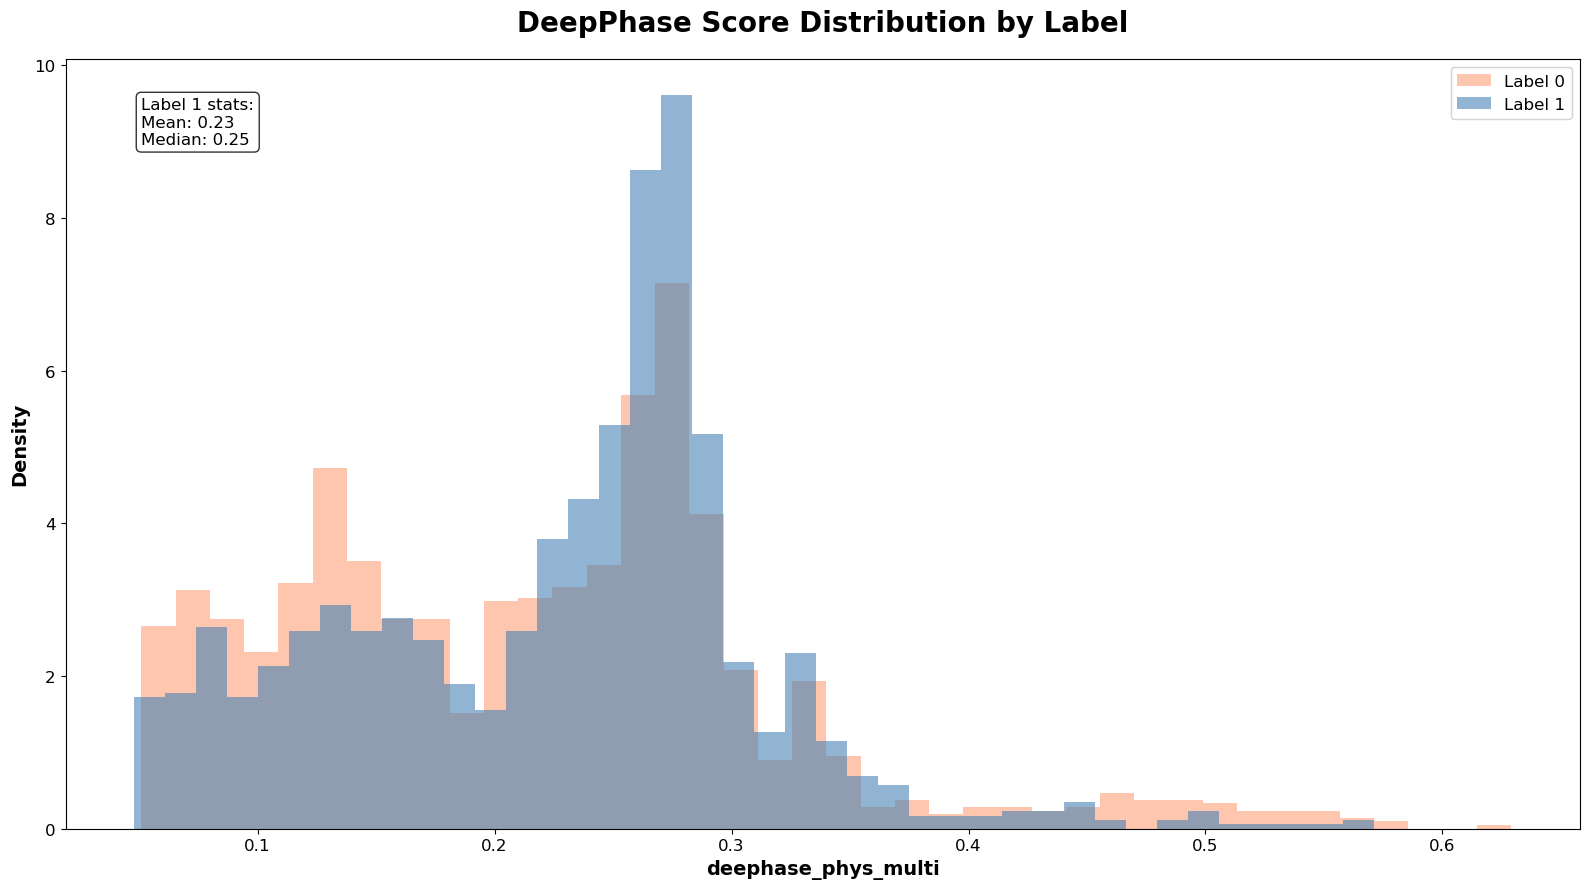

In [45]:
plot_deepphase_score_by_label(training_dataset_df, score_col="deephase_phys_multi")

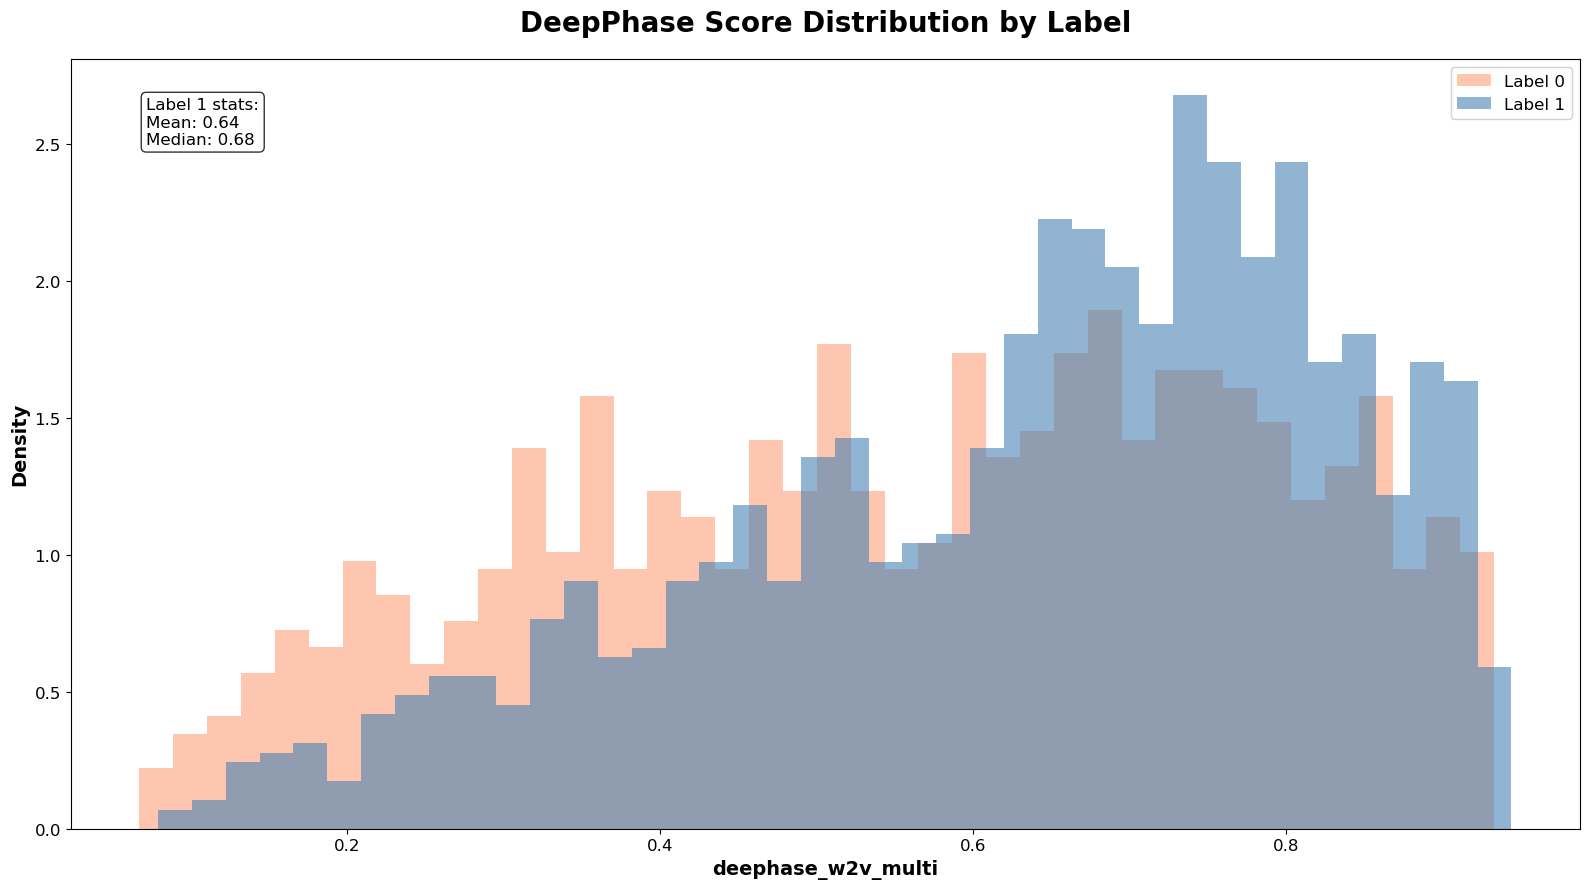

In [46]:
plot_deepphase_score_by_label(training_dataset_df, "deephase_w2v_multi")

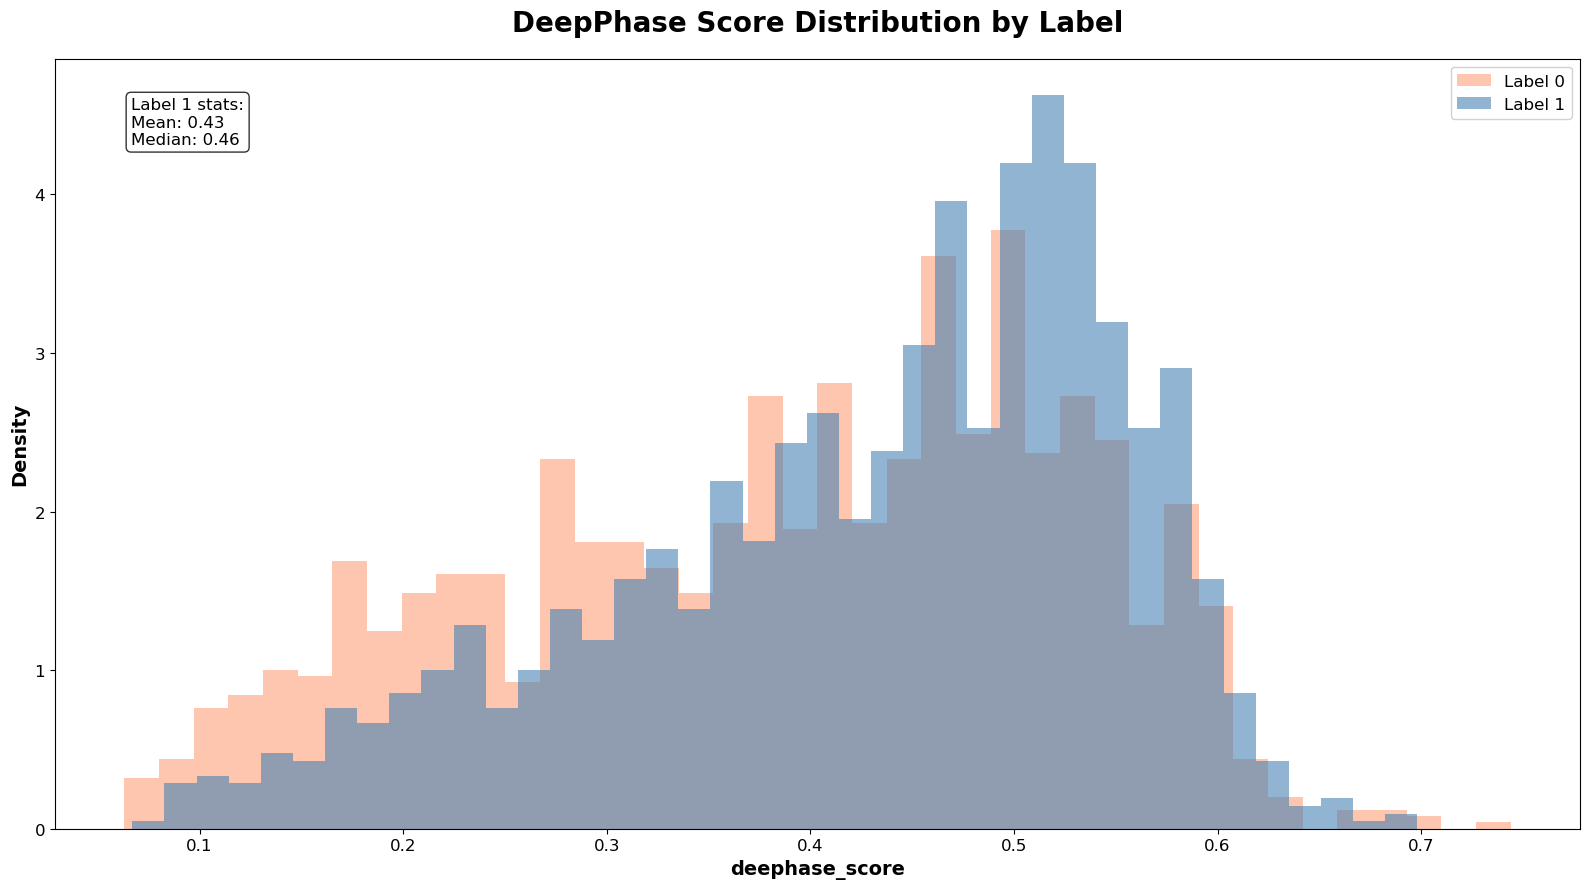

In [47]:
plot_deepphase_score_by_label(training_dataset_df, "deephase_score")

task 41: feature importance and its contribution were
further analyzed to find which feature was more valuable for
the model performance after feature selection 

In [48]:
# Prefixes for PLM features
plm_prefixes = (
    'esm_protein_embedding_',
    'esm_residue_embedding_',
    'ptmmamba_residue_embedding_',
    'ptmmamba_protein_embedding_'
)

# Identify PLM and Biological features
plm_features = [feature for feature in total_selected_features if feature.startswith(plm_prefixes)]
bio_features = [feature for feature in total_selected_features if not feature.startswith(plm_prefixes)]

# Counts
plm_count = len(plm_features)
bio_count = len(bio_features)

# Output
print(f"total features number: ({len(total_selected_features)})")
print(f"PLM features ({plm_count}): {plm_features}")
print(f"Biological features ({bio_count}): {bio_features}")

print(f"PLM features: {plm_count}")
print(f"Biological features: {bio_count}")

total features number: (707)
PLM features (699): ['esm_residue_embedding_1266', 'esm_residue_embedding_1223', 'esm_residue_embedding_248', 'esm_residue_embedding_143', 'esm_protein_embedding_817', 'ptmmamba_residue_embedding_520', 'esm_protein_embedding_737', 'esm_residue_embedding_922', 'esm_residue_embedding_196', 'esm_residue_embedding_78', 'esm_protein_embedding_1098', 'esm_residue_embedding_1138', 'esm_residue_embedding_725', 'ptmmamba_residue_embedding_344', 'ptmmamba_residue_embedding_510', 'ptmmamba_residue_embedding_415', 'esm_residue_embedding_1235', 'ptmmamba_protein_embedding_position_299', 'ptmmamba_residue_embedding_52', 'esm_protein_embedding_1014', 'esm_residue_embedding_107', 'esm_protein_embedding_151', 'esm_protein_embedding_19', 'ptmmamba_residue_embedding_112', 'esm_residue_embedding_223', 'ptmmamba_residue_embedding_593', 'esm_residue_embedding_1058', 'esm_residue_embedding_713', 'esm_residue_embedding_88', 'ptmmamba_residue_embedding_18', 'ptmmamba_residue_embedd

### 4.4	Prediction performance with different classifiers

task 42: To test the validity of the optimal feature set in different classifiers, three common classifiers were used to predict 14-3-3 sites: random forest (RF), XGBoost (XGB), SVM and ANN are used. 

In [49]:
# !pip install xgboost

In [50]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

classifer_lst = [RandomForestClassifier(max_depth=7), XGBClassifier(), SVC(), MLPClassifier()]

In [51]:
features = list(total_selected_features) + ["label", "augmentated from uniprot ID"]
training_dataset_df = pd.read_pickle("final_dataset_with_all_new.pkl")
training_dataset_df = training_dataset_df[training_dataset_df["usage"] == "training"]

In [52]:
len(features)

709

In [53]:
print(features)

['esm_residue_embedding_1266', 'esm_residue_embedding_1223', 'esm_residue_embedding_248', 'esm_residue_embedding_143', 'esm_protein_embedding_817', 'ptmmamba_residue_embedding_520', 'esm_protein_embedding_737', 'esm_residue_embedding_922', 'esm_residue_embedding_196', 'esm_residue_embedding_78', 'esm_protein_embedding_1098', 'esm_residue_embedding_1138', 'esm_residue_embedding_725', 'ptmmamba_residue_embedding_344', 'ptmmamba_residue_embedding_510', 'ptmmamba_residue_embedding_415', 'esm_residue_embedding_1235', 'ptmmamba_protein_embedding_position_299', 'ptmmamba_residue_embedding_52', 'esm_protein_embedding_1014', 'esm_residue_embedding_107', 'esm_protein_embedding_151', 'esm_protein_embedding_19', 'ptmmamba_residue_embedding_112', 'esm_residue_embedding_223', 'ptmmamba_residue_embedding_593', 'esm_residue_embedding_1058', 'esm_residue_embedding_713', 'esm_residue_embedding_88', 'ptmmamba_residue_embedding_18', 'ptmmamba_residue_embedding_575', 'esm_residue_embedding_1063', 'ptmmamba

In [54]:
for model in classifer_lst:
    train(training_dataset_df[features], model)

Label counts in y_train:
label
0    966
1    841
Name: count, dtype: int64

Label counts in y_test:
label
0    233
1    226
Name: count, dtype: int64
Model RandomForestClassifier(max_depth=7) Performance Metrics:

Training Data Metrics:
Accuracy: 0.97
MCC: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       966
           1       0.96      0.97      0.97       841

    accuracy                           0.97      1807
   macro avg       0.97      0.97      0.97      1807
weighted avg       0.97      0.97      0.97      1807


Test Data Metrics:
Accuracy: 0.81
MCC: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.84       233
           1       0.91      0.69      0.79       226

    accuracy                           0.81       459
   macro avg       0.83      0.81      0.81       459
weighted avg       0.83      0.81      0.81     

## final selection of the features using REFCV

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import BaseCrossValidator

class StratifiedGroupKFold(BaseCrossValidator):
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
        
    def split(self, X, y, groups):
        if isinstance(groups, np.ndarray):
            groups = pd.Series(groups)

        # Create a DataFrame containing labels and groups
        df = pd.DataFrame({'label': y, 'group': groups})
        
        # Calculate group counts and assign labels
        group_to_label = df.groupby('group')['label'].first().to_dict()
        group_counts = df.groupby('group').size().to_dict()
        
        labels, label_counts = np.unique(y, return_counts=True)
        rng = np.random.RandomState(self.random_state)

        # Split groups by label
        label_group_split = {label: [] for label in labels}
        for label, group in group_to_label.items():
            label_group_split[group].append(label)
        
        for label in labels:
            if self.shuffle:
                rng.shuffle(label_group_split[label])
        
        # Distribute groups into folds
        fold_splits = [{'groups': [], 'count': 0} for _ in range(self.n_splits)]
        for label in labels:
            for group in label_group_split[label]:
                fold_idx = np.argmin([f['count'] for f in fold_splits])
                fold_splits[fold_idx]['groups'].append(group)
                fold_splits[fold_idx]['count'] += group_counts[group]

        # Yield the train and test indices
        indices = np.arange(len(X))
        for fold in fold_splits:
            test_mask = groups.isin(fold['groups'])
            test_indices = indices[test_mask]
            train_indices = indices[~test_mask]
            yield train_indices, test_indices

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score, make_scorer

# Assuming you have defined the StratifiedGroupKFold class as above

# Load your dataset
df = pd.read_pickle("final_dataset_with_all_new.pkl")

# Assuming you've done preprocessing to load your features and target
features = []  # Replace with loading from your source
filename = "total_selected_features.txt"
with open(filename, 'r') as file:
    for line in file:
        feature = line.strip()
        if feature:
            features.append(feature)
total_selected_features = [feature.strip() for feature in features[0].split(',')]
features = list(total_selected_features) + ["label", "augmentated from uniprot ID"]

# Select the correct features and the target variable
df = df[df["usage"] == "training"][features].reset_index(drop=True)
target = "label"
used_features = df.columns.drop(target)
X = df[used_features]
y = df[target]

# Proceed with splitting
X_train, X_valid, y_train, y_valid = balanced_group_train_test_split(
    X,
    y,
    group_col='augmentated from uniprot ID',
    test_size=0.2,
    random_state=42, 
    drop_group_col=False
)

# Assign group labels
group_col = "augmentated from uniprot ID"
groups = X_train[group_col].values
X_train = X_train.drop(columns=[group_col])

# Initialize the Random Forest model
model = RandomForestClassifier(max_depth=7, random_state=42)

# Create a scoring function for AUC
auc_scorer = make_scorer(roc_auc_score, greater_is_better=True, needs_proba=True)

# Use the customized cross-validator
custom_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RFECV with the Random Forest model and AUC scoring
rfe_cv = RFECV(
    estimator=model,
    step=5,
    cv=custom_cv,
    scoring=auc_scorer,
    min_features_to_select=25, verbose=2
)

# Fit RFECV to the training data
rfe_cv.fit(X_train, y_train, groups=groups)

Fitting estimator with 707 features.
Fitting estimator with 702 features.
Fitting estimator with 697 features.
Fitting estimator with 692 features.
Fitting estimator with 687 features.
Fitting estimator with 682 features.
Fitting estimator with 677 features.
Fitting estimator with 672 features.
Fitting estimator with 667 features.
Fitting estimator with 662 features.
Fitting estimator with 657 features.
Fitting estimator with 652 features.
Fitting estimator with 647 features.
Fitting estimator with 642 features.
Fitting estimator with 637 features.
Fitting estimator with 632 features.
Fitting estimator with 627 features.
Fitting estimator with 622 features.
Fitting estimator with 617 features.
Fitting estimator with 612 features.
Fitting estimator with 607 features.
Fitting estimator with 602 features.
Fitting estimator with 597 features.
Fitting estimator with 592 features.
Fitting estimator with 587 features.
Fitting estimator with 582 features.
Fitting estimator with 577 features.
F

RFECV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
      estimator=RandomForestClassifier(max_depth=7, random_state=42),
      min_features_to_select=25,
      scoring=make_scorer(roc_auc_score, needs_proba=True), step=5, verbose=2)

In [57]:
optimal_features_mask = rfe_cv.support_
optimal_features = X_train.columns[optimal_features_mask]

print("Optimal number of features:", rfe_cv.n_features_)
print("Selected Features:", list(optimal_features))

Optimal number of features: 667
Selected Features: ['esm_residue_embedding_1266', 'esm_residue_embedding_1223', 'esm_residue_embedding_248', 'esm_residue_embedding_143', 'esm_protein_embedding_817', 'esm_protein_embedding_737', 'esm_residue_embedding_922', 'esm_residue_embedding_196', 'esm_residue_embedding_78', 'esm_protein_embedding_1098', 'esm_residue_embedding_1138', 'esm_residue_embedding_725', 'ptmmamba_residue_embedding_344', 'ptmmamba_residue_embedding_510', 'ptmmamba_residue_embedding_415', 'esm_residue_embedding_1235', 'ptmmamba_protein_embedding_position_299', 'ptmmamba_residue_embedding_52', 'esm_protein_embedding_1014', 'esm_residue_embedding_107', 'esm_protein_embedding_151', 'esm_protein_embedding_19', 'ptmmamba_residue_embedding_112', 'esm_residue_embedding_223', 'ptmmamba_residue_embedding_593', 'esm_residue_embedding_1058', 'esm_residue_embedding_713', 'esm_residue_embedding_88', 'ptmmamba_residue_embedding_18', 'ptmmamba_residue_embedding_575', 'esm_residue_embedding

In [58]:
# Transform datasets to include only selected features
X_train_selected = rfe_cv.transform(X_train)
X_valid_selected = rfe_cv.transform(X_valid.drop(columns=[group_col]))

# Re-fit model with selected features
model.fit(X_train_selected, y_train)

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report,
    matthews_corrcoef
)

# Use the trained model to predict on the validation set
y_pred_proba = model.predict_proba(X_valid_selected)[:, 1]  # Probabilities
y_pred = model.predict(X_valid_selected)  # Class labels

# Calculate AUC score
roc_auc = roc_auc_score(y_valid, y_pred_proba)
print(f"AUC: {roc_auc:.2f}")

# Calculate other performance metrics
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Calculate Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_valid, y_pred)
print(f"Matthews Correlation Coefficient: {mcc:.2f}")

# Display confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Detailed classification report
print("Classification Report:")
print(classification_report(y_valid, y_pred))

AUC: 0.93
Accuracy: 0.81
Precision: 0.91
Recall: 0.69
F1 Score: 0.78
Matthews Correlation Coefficient: 0.64
Confusion Matrix:
[[217  16]
 [ 70 156]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.83       233
           1       0.91      0.69      0.78       226

    accuracy                           0.81       459
   macro avg       0.83      0.81      0.81       459
weighted avg       0.83      0.81      0.81       459



## 4.5	Model architecture and optimization 

task 43: fine-tuned certain hyperparameters (Table X) of the model

In [59]:
features = []
filename = "total_selected_features.txt"
with open(filename, 'r') as file:
    for line in file:
        # Strip whitespace and add non-empty lines to features list
        feature = line.strip()
        if feature:  # Only add non-empty lines
            features.append(feature)
total_selected_features = [feature.strip() for feature in features[0].split(',')]
df = pd.read_pickle("final_dataset_with_all_new.pkl")
features = list(total_selected_features) + ["label", "augmentated from uniprot ID"]

In [60]:
# a custormized CV for gridsearch and REFCV
import numpy as np
from sklearn.model_selection import BaseCrossValidator

class StratifiedGroupKFold(BaseCrossValidator):
    """
    Stratified Group K-Fold cross-validator.
    Splits data into folds preserving class distribution while keeping groups intact.
    """
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X, y, groups):
        labels, label_counts = np.unique(y, return_counts=True)
        group_to_label = {group: y[idx[0]] for group, idx in X.groupby(groups).groups.items()}
        group_counts = X.groupby(groups).size()
        rng = np.random.RandomState(self.random_state)

        # Split groups by label
        label_group_split = {}
        for label in labels:
            label_groups = [g for g in groups.unique() if group_to_label[g] == label]
            if self.shuffle:
                rng.shuffle(label_groups)
            label_group_split[label] = label_groups

        # Distribute groups into folds
        fold_splits = [{'groups': [], 'count': 0} for _ in range(self.n_splits)]
        for label in labels:
            target_per_fold = label_counts[label] // self.n_splits
            for group in label_group_split[label]:
                group_size = group_counts[group]
                fold_idx = np.argmin([f['count'] for f in fold_splits])
                fold_splits[fold_idx]['groups'].append(group)
                fold_splits[fold_idx]['count'] += group_size

        # Generate indices for splits
        for fold in fold_splits:
            test_mask = groups.isin(fold['groups'])
            test_indices = X[test_mask].index
            train_indices = X[~test_mask].index
            yield (train_indices, test_indices)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [61]:
len(total_selected_features)

707

In [62]:
# After loading the DataFrame and filtering
df = df[df["usage"] == "training"][features].reset_index(drop=True)  # Reset index here
y = df["label"]
target = "label"
used_features = list(df.columns)
used_features.remove(target)
x = df[used_features]

# Proceed with splitting
X_train, X_valid, y_train, y_valid = balanced_group_train_test_split(
    x,
    y,
    group_col='augmentated from uniprot ID',
    test_size=0.2,
    random_state=42, 
    drop_group_col=False
)

# Reset indices of the split DataFrames
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Now assign groups and drop the group column
group_col = "augmentated from uniprot ID"
groups = X_train[group_col]
X_train = X_train.drop(columns=[group_col])

In [63]:
X_train

,esm_residue_embedding_1266,esm_residue_embedding_1223,esm_residue_embedding_248,esm_residue_embedding_143,esm_protein_embedding_817,ptmmamba_residue_embedding_520,esm_protein_embedding_737,esm_residue_embedding_922,esm_residue_embedding_196,esm_residue_embedding_78,...,esm_residue_embedding_165,esm_residue_embedding_320,esm_residue_embedding_447,ptmmamba_residue_embedding_390,esm_residue_embedding_417,ptmmamba_residue_embedding_547,esm_residue_embedding_1011,ptmmamba_residue_embedding_556,esm_protein_embedding_549,esm_protein_embedding_141
0,-0.049124,-0.191187,-0.187252,-0.070795,-0.017764,0.142052,0.026144,-0.146843,-0.171413,-0.278011,...,0.182671,0.179278,-0.000184,1.477223,0.156806,0.291596,0.122881,0.964228,-0.012305,-0.114025
1,-0.079403,-0.136351,-0.216524,-0.082297,0.025304,0.008178,0.094037,-0.119602,-0.173391,-0.305487,...,0.204586,0.194229,0.048128,0.949920,0.179893,0.465802,0.089925,1.481784,-0.036740,-0.145895
2,0.051093,-0.191472,-0.104982,-0.071691,-0.010991,-0.042699,0.055155,-0.159262,-0.122570,-0.232282,...,0.148960,0.215688,-0.049835,1.433811,0.248287,0.096514,0.041199,-0.841013,-0.028434,-0.108206
3,-0.130719,-0.030747,-0.213885,-0.185019,-0.030007,-0.895644,0.058250,-0.120952,-0.107382,-0.313558,...,0.115283,0.121214,0.121209,2.478415,0.203728,-0.492747,-0.004394,0.553024,-0.020221,-0.154805
4,-0.058494,-0.122087,-0.007470,-0.076396,-0.044334,0.584876,-0.022699,0.036504,-0.245540,-0.188608,...,-0.147911,0.338032,-0.049671,0.174294,0.145360,0.044472,-0.021879,0.453357,-0.000397,-0.025306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1802,0.210066,-0.089735,-0.000372,-0.022511,-0.022203,0.286835,-0.005393,0.020270,-0.033032,-0.141221,...,-0.034008,0.157581,0.008620,-0.230889,0.146507,-1.106401,-0.035685,0.618849,0.036020,-0.025411
1803,0.161967,-0.227048,0.056312,-0.167599,-0.081967,0.292979,-0.014909,0.007980,-0.101824,-0.179358,...,-0.083337,0.045894,-0.153631,-0.560025,0.096729,-0.806963,-0.022590,0.719489,-0.013905,-0.014020
1804,0.121653,0.036759,-0.076247,0.033045,-0.042170,-0.459404,-0.027239,-0.043135,0.139744,0.150860,...,-0.042485,-0.038889,-0.153210,-0.786915,-0.051171,-0.956223,0.002600,0.592536,0.011697,-0.055919
1805,0.115993,-0.203383,-0.087404,-0.067470,-0.064012,0.179392,-0.089423,0.063325,0.074478,-0.175534,...,-0.047841,0.414356,-0.067862,-0.763389,0.002083,-2.632035,-0.017014,1.280336,0.057753,-0.052580


In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
# Prepare data (ensure group column is excluded from features)
# group_col = "augmentated from uniprot ID"
# groups = X_train[group_col] # Pass this to GridSearchCV
# X_train = X_train.drop(columns=[group_col])

# Define model and hyperparameters
steps = [('classifier', XGBClassifier(tree_method= 'gpu_hist'))]
pipe = Pipeline(steps)

scorer = make_scorer(average_precision_score)

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2,3,4],
    'classifier__gamma': [0, 0.5, 1],
    'classifier__reg_alpha': [0, 0.5, 1],
    'classifier__reg_lambda': [0.5, 1, 5],
    'classifier__base_score': [0.2, 0.5, 1]
}

# param_grid = {
#     'classifier__n_estimators': [100],
#     'classifier__learning_rate': [0.01],
#     'classifier__max_depth': [2],
#     'classifier__gamma': [0],
#     'classifier__reg_alpha': [0],
#     'classifier__reg_lambda': [0.5, 1],
#     'classifier__base_score': [0.2, 0.5]
# }

# Initialize GridSearchCV with custom CV
custom_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
model_gsv = GridSearchCV(pipe, param_grid, cv=custom_cv, scoring = scorer, n_jobs=-1, verbose=2)

# Fit with groups
model_gsv = model_gsv.fit(X_train, y_train, groups=groups)
model_gsv.best_params_
best_xgboost_model = model_gsv.best_estimator_

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


In [65]:
model_gsv.best_params_

# {'classifier__base_score': 0.2,
#  'classifier__gamma': 0,
#  'classifier__learning_rate': 0.01,
#  'classifier__max_depth': 2,
#  'classifier__n_estimators': 100,
#  'classifier__reg_alpha': 0,
#  'classifier__reg_lambda': 0.5}

{'classifier__base_score': 0.2,
 'classifier__gamma': 0,
 'classifier__learning_rate': 0.01,
 'classifier__max_depth': 2,
 'classifier__n_estimators': 100,
 'classifier__reg_alpha': 0,
 'classifier__reg_lambda': 0.5}

In [66]:
X_train

,esm_residue_embedding_1266,esm_residue_embedding_1223,esm_residue_embedding_248,esm_residue_embedding_143,esm_protein_embedding_817,ptmmamba_residue_embedding_520,esm_protein_embedding_737,esm_residue_embedding_922,esm_residue_embedding_196,esm_residue_embedding_78,...,esm_residue_embedding_165,esm_residue_embedding_320,esm_residue_embedding_447,ptmmamba_residue_embedding_390,esm_residue_embedding_417,ptmmamba_residue_embedding_547,esm_residue_embedding_1011,ptmmamba_residue_embedding_556,esm_protein_embedding_549,esm_protein_embedding_141
0,-0.049124,-0.191187,-0.187252,-0.070795,-0.017764,0.142052,0.026144,-0.146843,-0.171413,-0.278011,...,0.182671,0.179278,-0.000184,1.477223,0.156806,0.291596,0.122881,0.964228,-0.012305,-0.114025
1,-0.079403,-0.136351,-0.216524,-0.082297,0.025304,0.008178,0.094037,-0.119602,-0.173391,-0.305487,...,0.204586,0.194229,0.048128,0.949920,0.179893,0.465802,0.089925,1.481784,-0.036740,-0.145895
2,0.051093,-0.191472,-0.104982,-0.071691,-0.010991,-0.042699,0.055155,-0.159262,-0.122570,-0.232282,...,0.148960,0.215688,-0.049835,1.433811,0.248287,0.096514,0.041199,-0.841013,-0.028434,-0.108206
3,-0.130719,-0.030747,-0.213885,-0.185019,-0.030007,-0.895644,0.058250,-0.120952,-0.107382,-0.313558,...,0.115283,0.121214,0.121209,2.478415,0.203728,-0.492747,-0.004394,0.553024,-0.020221,-0.154805
4,-0.058494,-0.122087,-0.007470,-0.076396,-0.044334,0.584876,-0.022699,0.036504,-0.245540,-0.188608,...,-0.147911,0.338032,-0.049671,0.174294,0.145360,0.044472,-0.021879,0.453357,-0.000397,-0.025306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1802,0.210066,-0.089735,-0.000372,-0.022511,-0.022203,0.286835,-0.005393,0.020270,-0.033032,-0.141221,...,-0.034008,0.157581,0.008620,-0.230889,0.146507,-1.106401,-0.035685,0.618849,0.036020,-0.025411
1803,0.161967,-0.227048,0.056312,-0.167599,-0.081967,0.292979,-0.014909,0.007980,-0.101824,-0.179358,...,-0.083337,0.045894,-0.153631,-0.560025,0.096729,-0.806963,-0.022590,0.719489,-0.013905,-0.014020
1804,0.121653,0.036759,-0.076247,0.033045,-0.042170,-0.459404,-0.027239,-0.043135,0.139744,0.150860,...,-0.042485,-0.038889,-0.153210,-0.786915,-0.051171,-0.956223,0.002600,0.592536,0.011697,-0.055919
1805,0.115993,-0.203383,-0.087404,-0.067470,-0.064012,0.179392,-0.089423,0.063325,0.074478,-0.175534,...,-0.047841,0.414356,-0.067862,-0.763389,0.002083,-2.632035,-0.017014,1.280336,0.057753,-0.052580


In [67]:
# Evaluate the best model on the test set
from sklearn.metrics import matthews_corrcoef

# Training set evaluation
y_train_proba = best_xgboost_model.predict_proba(X_train)[:, 1]
y_train_pred = best_xgboost_model.predict(X_train)
train_mcc = matthews_corrcoef(y_train, y_train_pred)
model_classification_report = classification_report(y_train, y_train_pred)

# Validation set evaluation
if "augmentated from uniprot ID" in X_valid.columns:
    X_valid = X_valid.drop(columns=[group_col])
y_valid_proba = best_xgboost_model.predict_proba(X_valid)[:, 1]
y_valid_pred = best_xgboost_model.predict(X_valid)
valid_mcc = matthews_corrcoef(y_valid, y_valid_pred)
model_classification_report_valid = classification_report(y_valid, y_valid_pred)

# Print evaluation results
print("XGBoost Model")
print("Training performance:")
print(f"Average Precision Score: {average_precision_score(y_train, y_train_proba):.3e}")
print(f"Matthews Correlation Coefficient: {train_mcc:.3f}")
print(f"Classification Report (Training data):")
print(model_classification_report)
print("-" * 50)

print("Validation performance:")
print(f"Average Precision Score: {average_precision_score(y_valid, y_valid_proba):.3e}")
print(f"Matthews Correlation Coefficient: {valid_mcc:.3f}")
print(f"Classification Report (Validation data):")
print(model_classification_report_valid)
print("-" * 50)

XGBoost Model
Training performance:
Average Precision Score: 9.217e-01
Matthews Correlation Coefficient: 0.697
Classification Report (Training data):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       966
           1       0.88      0.77      0.83       841

    accuracy                           0.85      1807
   macro avg       0.85      0.84      0.85      1807
weighted avg       0.85      0.85      0.85      1807

--------------------------------------------------
Validation performance:
Average Precision Score: 8.933e-01
Matthews Correlation Coefficient: 0.553
Classification Report (Validation data):
              precision    recall  f1-score   support

           0       0.72      0.89      0.80       233
           1       0.85      0.64      0.73       226

    accuracy                           0.77       459
   macro avg       0.79      0.77      0.76       459
weighted avg       0.79      0.77      0.77       459

-----

## 4.6 Feature Importance analysis

task 44: we conducted a thorough examination of feature importance using SHAP (SHapley Additive exPlanations) values

In [68]:
best_model = best_xgboost_model

In [69]:
# Get the feature importances from the XGBClassifier
feature_importances = best_model.named_steps['classifier'].feature_importances_

# Use the original feature names from your training data
feature_names = X_train.columns.tolist()  # Convert to list if needed

# Make sure the number of feature names matches the number of importance scores
if len(feature_names) == len(feature_importances):
    # Create a DataFrame to pair feature names with importance scores
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    
    # Sort by importance (descending)
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Display the top 20 most important features
    print("Top 20 most important features:")
    print(feature_importance_df[:50])
else:
    print(f"Warning: Number of feature names ({len(feature_names)}) doesn't match number of importance scores ({len(feature_importances)})")

Top 20 most important features:
                            Feature  Importance
598                     onehot_-3_R    0.225646
628        esm_residue_embedding_81    0.067771
225       esm_residue_embedding_960    0.061906
37                       onehot_2_P    0.060430
343       esm_residue_embedding_385    0.034223
89        esm_residue_embedding_989    0.032271
305       esm_residue_embedding_546    0.032100
538      esm_residue_embedding_1215    0.031174
636       esm_residue_embedding_450    0.031120
370      esm_residue_embedding_1131    0.030199
33        esm_residue_embedding_235    0.030153
479       esm_residue_embedding_727    0.029593
159        esm_residue_embedding_11    0.029336
352       esm_residue_embedding_293    0.029207
449       esm_residue_embedding_944    0.028875
632       esm_residue_embedding_200    0.028783
220       esm_residue_embedding_327    0.028674
79        esm_residue_embedding_384    0.023226
59        esm_residue_embedding_440    0.022841
222     

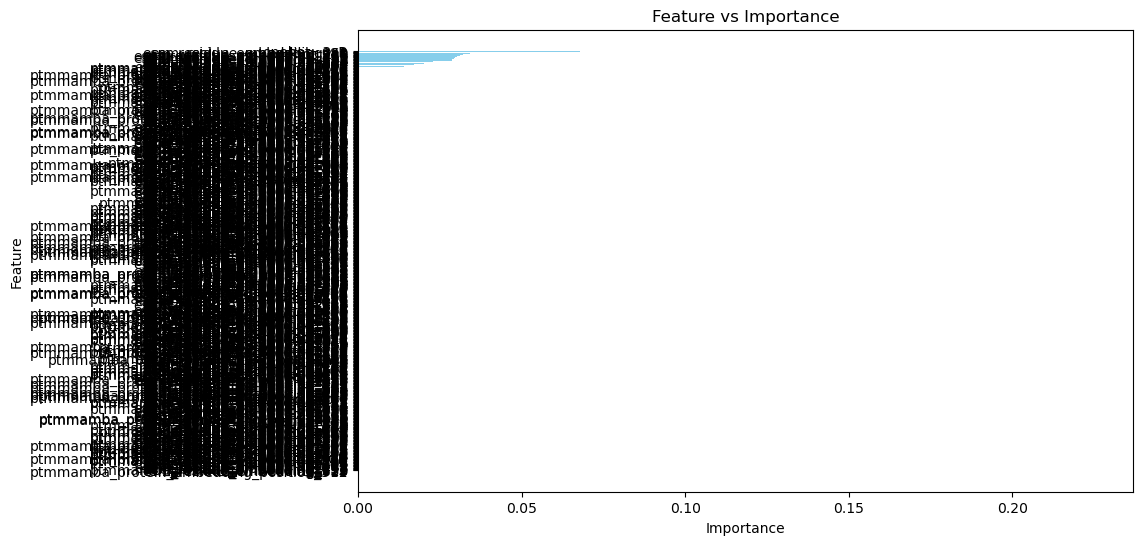

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Sorting the DataFrame based on the 'Value' column in descending order
df_sorted = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plotting the data
plt.figure(figsize=(10, 6))  # Set the figure size
plt.barh(df_sorted.iloc[:, 0], df_sorted.iloc[:, 1], color='skyblue')  # Create a horizontal bar plot

# Adding title and labels
plt.title('Feature vs Importance')
plt.ylabel(df_sorted.columns[0])
plt.xlabel(df_sorted.columns[1])

# Display the plot
plt.show()

In [71]:
# !pip install shap

In [72]:
import shap
xgboost_model = best_model.named_steps['classifier']
# print(type(random_forest_model))
# Create a SHAP explainer

# Create a SHAP explainer
explainer = shap.TreeExplainer(xgboost_model)

# Calculate SHAP values
shap_values = explainer(X_train[feature_names])

# # Visualize feature importance with feature values
# shap.plots.beeswarm(shap_values, show=True)

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import shap

def custom_beeswarm(shap_values, feature_names):
    # Convert SHAP values to a 2D array if it's not already
    if len(shap_values.shape) == 1:
        shap_values = shap_values.reshape(1, -1)
    
    # Obtain the mean absolute SHAP value for each feature to determine order
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feature_order = np.argsort(mean_abs_shap)[::-1]
    
    # Prepare the plot
    plt.figure(figsize=(10, 6))
    
    # Loop through each feature
    for i, feature_idx in enumerate(feature_order):
        # Extract current feature's SHAP values
        shap_feature_values = shap_values[:, feature_idx]
        
        # Get colors based on SHAP values to simulate original beeswarm visual cues
        colors = plt.cm.coolwarm((shap_feature_values - shap_feature_values.min()) / (shap_feature_values.max() - shap_feature_values.min()))
        
        # Generate jittered y positions for the beeswarm effect
        y_positions = np.random.normal(loc=i, scale=0.1, size=shap_feature_values.shape)
        
        # Scatter plot
        plt.scatter(shap_feature_values, y_positions, color=colors, alpha=0.7, s=10, edgecolor='k', linewidth=0.5)
    
    # Set feature names as y-axis labels
    plt.yticks(ticks=np.arange(len(feature_names)), labels=[feature_names[i] for i in feature_order])
    plt.xlabel('SHAP value (Impact on model output)')
    plt.title('Custom SHAP Beeswarm Plot')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Usage
# Assume X_train[feature_names] is the correct DataFrame for the features
# Ensure you have already calculated the shap_values
custom_beeswarm(shap_values, feature_names)

TypeError: bad operand type for abs(): 'Explanation'

task 45: ablation experiments where we systematically removed features to observe changes in model performance.

## 4.7	Performance evaluation and comparison with existing methods, Validation on independent test sets

task 46: Independent datset test with 14-3-3 pred and 14-3-3 site-finder, compare with our results.